## Data Modelling - Retrieval
In this step, we are going to try Tensorflow recommender framework. 

TensorFlow Recommenders (TFRS) is a library for building recommender system models. It helps with the full workflow of building a recommender system: data preparation, model formulation, training, evaluation, and deployment. It's built on Keras and aims to have a gentle learning curve while still giving you the flexibility to build complex models.

At first the plan was using different library, after we got the course "Deep Learning with Tensorflow", we decided to use it.

We are going to start with retrieval model. The retrieval model is responsible for selecting an initial set of hundreds of candidates from all possible candidates. The main objective of this model is to efficiently weed out all candidates that the user is not interested in. Because the retrieval model may be dealing with millions of candidates, it has to be computationally efficient.

#### Load pandas dataframe and convert into Tensorflow dataset

Pandas dataframes are great but for Tensorflow it is required to convert into tensorflow dataset. 
https://www.tensorflow.org/api_docs/python/tf/data/Dataset

In [1]:
#Install tensor libraries
!pip install -q tensorflow
!pip install -q tensorflow-recommenders
!pip install -q tensorflow-ranking
!pip install -q numpy

In [2]:
import pandas as pd
#load dataframes from csv files created in previous steps
file_path = "dataset/ratebeer_dataset.csv"
df = pd.read_csv(file_path)
file_path_beers = "dataset/ratebeer_beers.csv"
df_beers = pd.read_csv(file_path_beers)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2006599 entries, 0 to 2006598
Data columns (total 13 columns):
 #   Column             Dtype  
---  ------             -----  
 0   beer_name          object 
 1   beer_id            int64  
 2   brewer_id          int64  
 3   beer_abv           float64
 4   beer_style         object 
 5   review_appearance  float64
 6   review_aroma       float64
 7   review_palate      float64
 8   review_taste       float64
 9   review_overall     float64
 10  review_time        int64  
 11  review_username    object 
 12  review_text        object 
dtypes: float64(6), int64(3), object(4)
memory usage: 199.0+ MB


In [6]:
import tensorflow as tf
import tensorflow_recommenders as tfrs
from typing import Dict, Text
# Tensorflow dataset for ratings
def get_ratings_in_tensor_dataset(df):
    #Drop review_text as it is quite large to create a tensor dataset
    df_without_review = df.drop(columns=['review_text'])
    ratings = tf.data.Dataset.from_tensor_slices(dict(df_without_review)).map(lambda x: {
        "beer_id": x["beer_id"],
        "beer_name": x["beer_name"],
        "brewer_id": x["brewer_id"],
        "beer_style": x["beer_style"],
        "beer_abv": x["beer_abv"],
        "review_username": x["review_username"],
        "review_overall": x["review_overall"],
        "review_taste": x["review_taste"],
        "review_palate": x["review_palate"],
        "review_appearance": x["review_appearance"],
        "review_aroma": x["review_aroma"]
    })
    return ratings

# Tensorflow dataset for beers
def get_beers_in_tensor_dataset(df_beers):
    beers = tf.data.Dataset.from_tensor_slices(dict(df_beers)).map(lambda x: {
        "beer_id": x["beer_id"],
        "beer_name": x["beer_name"],
        "beer_abv": x["beer_abv"],
        "beer_style": x["beer_style"],
        "brewer_id": x["brewer_id"]
    })
    return beers


# Converting in tensor dataset
ratings = get_ratings_in_tensor_dataset(df)
beers = get_beers_in_tensor_dataset(df_beers)

#### Dictionary for embeddings
Embeddings are essential in TensorFlow recommender systems because they efficiently convert high-dimensional, sparse categorical data (like usernames, beer IDs, and beer styles) into lower-dimensional, dense vectors.

This conversion is not only computationally efficient but also captures underlying semantic relationships and user preferences, making it ideal for personalized recommendations. 

Embeddings allow the model to understand nuanced user-beer interactions and characteristics, leading to more accurate and contextually relevant recommendations. 

The function prepare_dictionary_for_embeddings sets up the necessary unique values for each attributes, ensuring efficient handling and processing of both categorical and continuous data in the recommendation system.

In [7]:
import numpy as np

def prepare_dictionary_for_embeddings(ratings, beers, embedding_dimension):
    # We need a vocabulary that maps a raw feature value to an integer in a contiguous range
    # this allows us to look up the corresponding embeddings in our embedding tables.
    usernames = ratings.batch(1_000).map(lambda x: x["review_username"])
    unique_usernames = np.unique(np.concatenate(list(usernames)))

    beer_ids = beers.batch(1_000).map(lambda x: x["beer_id"])
    unique_beer_ids = np.unique(np.concatenate(list(beer_ids)))

    # Now add also beer style into the retrieval model
    beer_styles = beers.batch(1_000).map(lambda x: x["beer_style"])
    unique_beer_styles = np.unique(np.concatenate(list(beer_styles)))

    # Now add also beer name into the retrieval model
    beer_names = beers.batch(1_000).map(lambda x: x["beer_name"])
    unique_beer_names = np.unique(np.concatenate(list(beer_styles)))

    #Add beer_abvs, this value will be used in the model too
    beer_abvs = np.concatenate(list(ratings.map(lambda x: x["beer_abv"]).batch(100)))

    max_beer_abv = beer_abvs.max()
    min_beer_abv = beer_abvs.min()

    beer_abv_buckets = np.linspace(
        min_beer_abv, max_beer_abv, num=1000,
    )
    return {
        "embedding_dimension": embedding_dimension,
        "unique_usernames": unique_usernames,
        "unique_beer_ids": unique_beer_ids,
        "unique_beer_styles": unique_beer_styles,
        "unique_beer_names": unique_beer_names,
        "beer_abv_buckets": beer_abv_buckets
    }

#Let's start with embedding size 32
embedding_dicts = prepare_dictionary_for_embeddings(ratings, beers, 32)

#### Preparing for train and test data
The function in the next cell is designed to prepare a training and testing dataset from a larger dataset of ratings for recommendation model that we will create
The ratings dataset is shuffled with a fixed sample size and seed.
The test and training sets are batched (with a smaller batch size) and cached for efficiency.

In [8]:
def get_train_test_cached(ratings, sample_size, batch_size=500):
    tf.random.set_seed(42)
    shuffled = ratings.shuffle(sample_size, seed=42, reshuffle_each_iteration=False)
    train_size = int(sample_size * 0.8)
    test_size = int(sample_size * 0.2)
    train = shuffled.take(train_size)
    test = shuffled.skip(train_size).take(test_size)
    print(f"The sample has a size of {sample_size}. Training size is {train_size}, test size is {test_size} and batch size is{batch_size}" )

    #Cache the dataset for better performance 
    cached_train = train.shuffle(train_size).batch(batch_size).cache()
    cached_test = test.batch(int(batch_size/4)).cache()
    return cached_train, cached_test

### Retrieval models
The retrieval stage is responsible for selecting an initial set of hundreds of candidates from all possible candidates. The main objective of this model is to efficiently weed out all candidates that the user is not interested in. Because the retrieval model may be dealing with millions of candidates, it has to be computationally efficient.

Retrieval models are often composed of two sub-models:

- A query model (for our case it represents users) computing the query representation (normally a fixed-dimensionality embedding vector) using query features.
- A candidate model (for our case it represent beers) computing the candidate representation (an equally-sized vector) using the candidate features

The outputs of the two models are then multiplied together to give a query-candidate affinity score, with higher scores expressing a better match between the candidate and the query.

In the following cells, we are going to create different models with differences by changing embeddings. 

#### BeerRecommendationModelV1
The BeerRecommendationModelV1 is a retrieval model for a recommendation system using TensorFlow Recommenders (TFRS). It's based on collaborative filtering, specifically matrix factorization, and works by learning embeddings for users and beers. Here's an overview of its components:

##### Beer Model (Candidate Model):
This part of the model is responsible for learning embeddings for beers.
It uses an IntegerLookup layer to convert beer IDs into integer indices.
An Embedding layer then learns a dense vector (embedding) for each beer ID. The size of these embeddings is determined by dicts["embedding_dimension"].


##### User Model (Query Model):
This part learns embeddings for users.
It uses a StringLookup layer to convert usernames into integer indices.
An Embedding layer then learns a dense vector for each username, with the same embedding dimension as the beer model.

##### Retrieval Task:
This layer defines the task of the model, which is retrieval.
The tfrs.tasks.Retrieval layer is used to compute the loss function necessary for training the model.
It uses FactorizedTopK metric, which computes the model's performance as the ability to retrieve the correct beer embeddings from a batch of candidate beers.
The candidates are batched beers, where each beer ID is transformed through the beer model to get its embedding.


##### Loss Computation:
In the compute_loss method, the model takes user and beer features (usernames and beer IDs).
It computes embeddings for both using the respective models.
The task's loss is computed based on how well the user embeddings match with the positive beer embeddings (i.e., beers that users interacted with).

##### Overall Working:
The model essentially learns to map users and beers into a shared embedding space where users are close to the beers they prefer.
During inference, given a user's embedding, the model can suggest beers whose embeddings are close to that user's embedding.
This model is a basic version of a collaborative filtering recommendation system where the focus is on learning good embeddings for users and items (beers) based on user-item interactions. 

In [9]:
# Retrieval model version 1
# Using matrix factorization (collabrative-filtering) with username-beer-id pairs. 
# Query model : username / Candidate model: beer id
class BeerRecommendationModelV1(tfrs.models.Model):
  def __init__(self,dicts, beers):
    super().__init__()
    self.beer_model: tf.keras.Model = tf.keras.Sequential([
        tf.keras.layers.IntegerLookup(vocabulary=dicts["unique_beer_ids"], mask_token=None),
        tf.keras.layers.Embedding(len(dicts["unique_beer_ids"]) + 1, dicts["embedding_dimension"])
    ])
    self.user_model: tf.keras.Model = tf.keras.Sequential([
        tf.keras.layers.StringLookup(vocabulary=dicts["unique_usernames"], mask_token=None),
        tf.keras.layers.Embedding(len(dicts["unique_usernames"]) + 1, dicts["embedding_dimension"])
    ])
    self.task: tf.keras.layers.Layer = tfrs.tasks.Retrieval(
        metrics=tfrs.metrics.FactorizedTopK(candidates=beers.batch(1024).map(lambda x: x["beer_id"]).map(self.beer_model)))

  def compute_loss(self, features: Dict[Text, tf.Tensor], training=False) -> tf.Tensor:
    # We pick out the user features and pass them into the user model.
    user_embeddings = self.user_model(features["review_username"])
    # And pick out the beer features and pass them into the movie model,
    # getting embeddings back.
    positive_beer_embeddings = self.beer_model(features["beer_id"])
    # The task computes the loss and the metrics.
    return self.task(user_embeddings, positive_beer_embeddings)
  def get_model_name(self):
    return "BeerRetrievalV1"

##### Fitting and evaluate models
To measure the accuracy and all the metrics, we need to use with different hyperparameters and save them. 

Then after that we can compare to find the optimum parameters. 

To make our life easier, there are some methods which parse the result and save it in an array. By using this array, we can create a dataframe and compare the results for different models.

In [10]:
#Use this function to print out test result of the model for retrieval
def get_test_metrics_retrieval(hyper_params, test_result, model_name, sample_number):
    top_1_accuracy = test_result['factorized_top_k/top_1_categorical_accuracy']
    top_5_accuracy = test_result['factorized_top_k/top_5_categorical_accuracy']
    top_10_accuracy = test_result['factorized_top_k/top_10_categorical_accuracy']
    top_50_accuracy = test_result['factorized_top_k/top_50_categorical_accuracy']
    top_100_accuracy = test_result['factorized_top_k/top_100_categorical_accuracy']
    loss = test_result['loss']
    total_loss = test_result['total_loss']
    number_of_epochs = hyper_params["epochs"]
    learning_rate = hyper_params["learning_rate"]

    metrics_dict = {
        'sample_number': sample_number,
        'model_name': model_name,
        'total_epochs': number_of_epochs,
        'last_epoch' : 0, #This is training no epoch
        'learning_rate': learning_rate,
        'top_1_accuracy': top_1_accuracy,
        'top_5_accuracy': top_5_accuracy,
        'top_10_accuracy': top_10_accuracy,
        'top_50_accuracy': top_50_accuracy,
        'top_100_accuracy': top_100_accuracy,
        'loss': loss,
        'total_loss': total_loss,
        'is_training': False
    }
    return metrics_dict;

#Use this function to print out test result of the model for retrieval
def get_training_metrics_retrieval(hyper_params, training_results, model_name, sample_number):
    # Get the total number of epochs
    total_epochs = len(training_results.history['loss'])

    # Retrieve metrics from the last epoch
    last_epoch = total_epochs - 1
    top_1_accuracy = training_results.history['factorized_top_k/top_1_categorical_accuracy'][last_epoch]
    top_5_accuracy = training_results.history['factorized_top_k/top_5_categorical_accuracy'][last_epoch]
    top_10_accuracy = training_results.history['factorized_top_k/top_10_categorical_accuracy'][last_epoch]
    top_50_accuracy = training_results.history['factorized_top_k/top_50_categorical_accuracy'][last_epoch]
    top_100_accuracy = training_results.history['factorized_top_k/top_100_categorical_accuracy'][last_epoch]
    loss = training_results.history['loss'][last_epoch]
    total_loss = training_results.history['total_loss'][last_epoch]
    learning_rate = hyper_params["learning_rate"]

    metrics_dict = {
        'model_name': model_name,
        'sample_number': sample_number,
        'total_epochs': hyper_params['epochs'],
        'last_epoch': last_epoch,
        'learning_rate': learning_rate,
        'top_1_accuracy': top_1_accuracy,
        'top_5_accuracy': top_5_accuracy,
        'top_10_accuracy': top_10_accuracy,
        'top_50_accuracy': top_50_accuracy,
        'top_100_accuracy': top_100_accuracy,
        'loss': loss,
        'total_loss': total_loss,
        'is_training': True
    }
    return metrics_dict

In [13]:
sample_size = 308103 #Everything
learning_rates = [0.1, 0.01]
epochs=[3, 10, 20]

cached_train, cached_test = get_train_test_cached(ratings, sample_size, batch_size = 10000)

metrics_list = []
for epoch in epochs:
    for learning_rate in learning_rates:
        model_retrieval = BeerRecommendationModelV1(embedding_dicts,beers)
        model_retrieval.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=learning_rate))
        print('Model name:',  model_retrieval.get_model_name())
        sample_number = 1 #all records in one shot

        callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3, min_delta = 300)

        training_results = model_retrieval.fit(cached_train, epochs=epoch, verbose=1, callbacks=callback)
        training_metrics = get_training_metrics_retrieval({"learning_rate" : learning_rate, "epochs": epoch}, training_results, model_retrieval.get_model_name(), sample_number)
        metrics_list.append(training_metrics)

        test_result = model_retrieval.evaluate(cached_test, return_dict=True, verbose=1)
        test_metrics = get_test_metrics_retrieval({"learning_rate" : learning_rate, "epochs": epoch}, test_result, model_retrieval.get_model_name(), sample_number)
        metrics_list.append(test_metrics)

df_retrieval_metrics_v1 = pd.DataFrame(metrics_list) 
df_retrieval_metrics_v1

The sample has a size of 308103. Training size is 246482, test size is 61620 and batch size is10000
Model name: BeerRetrievalV1
Epoch 1/3
25/25 [==============================] - 15s 426ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0039 - factorized_top_k/top_5_categorical_accuracy: 0.0265 - factorized_top_k/top_10_categorical_accuracy: 0.0580 - factorized_top_k/top_50_categorical_accuracy: 0.3015 - factorized_top_k/top_100_categorical_accuracy: 0.5710 - loss: 89008.5965 - regularization_loss: 0.0000e+00 - total_loss: 89008.5965
Epoch 2/3
25/25 [==============================] - 12s 493ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0079 - factorized_top_k/top_5_categorical_accuracy: 0.0472 - factorized_top_k/top_10_categorical_accuracy: 0.0913 - factorized_top_k/top_50_categorical_accuracy: 0.3889 - factorized_top_k/top_100_categorical_accuracy: 0.6668 - loss: 88091.6157 - regularization_loss: 0.0000e+00 - total_loss: 88091.6157
Epoch 3/3
25/25 [===================

25/25 [==============================] - 12s 431ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0031 - factorized_top_k/top_5_categorical_accuracy: 0.0212 - factorized_top_k/top_10_categorical_accuracy: 0.0441 - factorized_top_k/top_50_categorical_accuracy: 0.2360 - factorized_top_k/top_100_categorical_accuracy: 0.4830 - loss: 89396.6034 - regularization_loss: 0.0000e+00 - total_loss: 89396.6034
Epoch 2/10
25/25 [==============================] - 11s 427ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0051 - factorized_top_k/top_5_categorical_accuracy: 0.0328 - factorized_top_k/top_10_categorical_accuracy: 0.0660 - factorized_top_k/top_50_categorical_accuracy: 0.3074 - factorized_top_k/top_100_categorical_accuracy: 0.5731 - loss: 89381.9450 - regularization_loss: 0.0000e+00 - total_loss: 89381.9450
Epoch 3/10
25/25 [==============================] - 10s 419ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0069 - factorized_top_k/top_5_categorical_accuracy: 0.044

25/25 [==============================] - 11s 425ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0051 - factorized_top_k/top_5_categorical_accuracy: 0.0332 - factorized_top_k/top_10_categorical_accuracy: 0.0662 - factorized_top_k/top_50_categorical_accuracy: 0.3040 - factorized_top_k/top_100_categorical_accuracy: 0.5676 - loss: 89383.5102 - regularization_loss: 0.0000e+00 - total_loss: 89383.5102
Epoch 3/20
25/25 [==============================] - 10s 417ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0077 - factorized_top_k/top_5_categorical_accuracy: 0.0457 - factorized_top_k/top_10_categorical_accuracy: 0.0876 - factorized_top_k/top_50_categorical_accuracy: 0.3704 - factorized_top_k/top_100_categorical_accuracy: 0.6438 - loss: 89341.9660 - regularization_loss: 0.0000e+00 - total_loss: 89341.9660
Epoch 4/20
25/25 [==============================] - 3s 85ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0054 - factorized_top_k/top_5_categorical_accuracy: 0.0316 

,model_name,sample_number,total_epochs,last_epoch,learning_rate,top_1_accuracy,top_5_accuracy,top_10_accuracy,top_50_accuracy,top_100_accuracy,loss,total_loss,is_training
0,BeerRetrievalV1,1,3,2,0.10,0.010260,0.058495,0.109347,0.431066,0.707309,55589.332031,55589.332031,True
1,BeerRetrievalV1,1,3,0,0.10,0.003668,0.028546,0.062480,0.332895,0.622850,11859.043945,11859.043945,False
2,BeerRetrievalV1,1,3,2,0.01,0.007550,0.044920,0.086485,0.365844,0.639341,56829.007812,56829.007812,True
3,BeerRetrievalV1,1,3,0,0.01,0.004706,0.029714,0.060289,0.308504,0.585151,11961.416992,11961.416992,False
4,BeerRetrievalV1,1,10,9,0.10,0.012435,0.076659,0.145439,0.520290,0.784000,54596.652344,54596.652344,True
5,BeerRetrievalV1,1,10,0,0.10,0.001574,0.014687,0.037082,0.282230,0.577702,12079.731445,12079.731445,False
6,BeerRetrievalV1,1,10,3,0.01,0.007729,0.047521,0.092790,0.378068,0.654088,56721.824219,56721.824219,True
7,BeerRetrievalV1,1,10,0,0.01,0.004495,0.031532,0.064979,0.321032,0.604885,11940.958984,11940.958984,False
8,BeerRetrievalV1,1,20,11,0.10,0.012330,0.077413,0.147861,0.524752,0.787100,54543.285156,54543.285156,True
9,BeerRetrievalV1,1,20,0,0.10,0.001428,0.014054,0.035605,0.280591,0.576355,12118.327148,12118.327148,False


#### Rest of models
The rest of models for retrieval has differences with the query and candidate inputs. 

Each model has a version and an explanation as a comment

In [12]:
# Retrieval model version 2
# In this model, we also added beer style on the candidate model (beer)
# Query model : username / Candidate model: beer id and beer style
class UserRetrievalModelV2(tfrs.models.Model):
    def __init__(self,unique_usernames, embedding_dimension):
        super().__init__()
        self.user_model: tf.keras.Model = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_usernames, mask_token=None, name="username_lookup"),
            tf.keras.layers.Embedding(len(unique_usernames) + 1, embedding_dimension, name="username_embedding")
        ], name="user_model_sequential")

    def call(self, inputs):
        return self.user_model(inputs["review_username"])

class BeerRetrievalModelV2(tfrs.models.Model):
    def __init__(self,unique_beer_ids, unique_beer_styles, embedding_dimension):
        super().__init__()
        self.beer_model: tf.keras.Model = tf.keras.Sequential([
            tf.keras.layers.IntegerLookup(vocabulary=unique_beer_ids, mask_token=None, name="beer_id_lookup"),
            tf.keras.layers.Embedding(len(unique_beer_ids) + 1, embedding_dimension, name="beer_id_embedding")
        ])
        self.beer_style_model: tf.keras.Model = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_beer_styles, mask_token=None,name="beer_style_lookup"),
            tf.keras.layers.Embedding(len(unique_beer_styles) + 1, embedding_dimension, name="beer_style_embedding")
        ])

    def call(self, inputs):
        return tf.concat([
            self.beer_model(inputs["beer_id"]),
            self.beer_style_model(inputs["beer_style"]),
        ], axis=1)

class BeerRecommendationModelV2(tfrs.models.Model):
    def __init__(self,dicts, beers):
        super().__init__()
        self.query_model = tf.keras.Sequential([
          UserRetrievalModelV2(dicts["unique_usernames"],dicts["embedding_dimension"]),
          tf.keras.layers.Dense(dicts["embedding_dimension"])
        ])
        self.candidate_model = tf.keras.Sequential([
          BeerRetrievalModelV2(dicts["unique_beer_ids"], dicts["unique_beer_styles"],dicts["embedding_dimension"]),
          tf.keras.layers.Dense(dicts["embedding_dimension"])
        ])
        self.task = tfrs.tasks.Retrieval(
            metrics=tfrs.metrics.FactorizedTopK(
                candidates=beers.batch(1024).map(self.candidate_model),
            ),
        )

    def compute_loss(self, features, training=False):
        query_embeddings = self.query_model({
            "review_username": features["review_username"]
        })
        candidate_embeddings = self.candidate_model({
            "beer_id": features["beer_id"],
            "beer_style": features["beer_style"]})

        return self.task(query_embeddings, candidate_embeddings)
    def get_model_name(self):
        return "BeerRetrievalV2"

In [14]:
metrics_list = []
for epoch in epochs:
    for learning_rate in learning_rates:
        model_retrieval = BeerRecommendationModelV2(embedding_dicts,beers)
        model_retrieval.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=learning_rate))
        print('Model name:',  model_retrieval.get_model_name())
        sample_number = 1 #all records in one shot
        
        callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3, min_delta = 300)

        training_results = model_retrieval.fit(cached_train, epochs=epoch, verbose=1, callbacks=callback)
        training_metrics = get_training_metrics_retrieval({"learning_rate" : learning_rate, "epochs": epoch}, training_results, model_retrieval.get_model_name(), sample_number)
        metrics_list.append(training_metrics)

        test_result = model_retrieval.evaluate(cached_test, return_dict=True, verbose=1)
        test_metrics = get_test_metrics_retrieval({"learning_rate" : learning_rate, "epochs": epoch}, test_result, model_retrieval.get_model_name(), sample_number)
        metrics_list.append(test_metrics)

df_retrieval_metrics_v2 = pd.DataFrame(metrics_list) 
df_retrieval_metrics_v2

Model name: BeerRetrievalV2
Epoch 1/3
25/25 [==============================] - 12s 436ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0040 - factorized_top_k/top_5_categorical_accuracy: 0.0291 - factorized_top_k/top_10_categorical_accuracy: 0.0599 - factorized_top_k/top_50_categorical_accuracy: 0.2977 - factorized_top_k/top_100_categorical_accuracy: 0.5621 - loss: 89183.5225 - regularization_loss: 0.0000e+00 - total_loss: 89183.5225
Epoch 2/3
25/25 [==============================] - 11s 426ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0062 - factorized_top_k/top_5_categorical_accuracy: 0.0401 - factorized_top_k/top_10_categorical_accuracy: 0.0811 - factorized_top_k/top_50_categorical_accuracy: 0.3680 - factorized_top_k/top_100_categorical_accuracy: 0.6455 - loss: 88366.0715 - regularization_loss: 0.0000e+00 - total_loss: 88366.0715
Epoch 3/3
25/25 [==============================] - 3s 88ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0053 - factorized_top_k

25/25 [==============================] - 12s 421ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0038 - factorized_top_k/top_5_categorical_accuracy: 0.0264 - factorized_top_k/top_10_categorical_accuracy: 0.0548 - factorized_top_k/top_50_categorical_accuracy: 0.2711 - factorized_top_k/top_100_categorical_accuracy: 0.5281 - loss: 89316.5799 - regularization_loss: 0.0000e+00 - total_loss: 89316.5799
Epoch 2/10
25/25 [==============================] - 11s 430ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0048 - factorized_top_k/top_5_categorical_accuracy: 0.0328 - factorized_top_k/top_10_categorical_accuracy: 0.0679 - factorized_top_k/top_50_categorical_accuracy: 0.3292 - factorized_top_k/top_100_categorical_accuracy: 0.6132 - loss: 88745.1791 - regularization_loss: 0.0000e+00 - total_loss: 88745.1791
Epoch 3/10
25/25 [==============================] - 11s 430ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0055 - factorized_top_k/top_5_categorical_accuracy: 0.037

25/25 [==============================] - 11s 427ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0048 - factorized_top_k/top_5_categorical_accuracy: 0.0333 - factorized_top_k/top_10_categorical_accuracy: 0.0697 - factorized_top_k/top_50_categorical_accuracy: 0.3364 - factorized_top_k/top_100_categorical_accuracy: 0.6185 - loss: 88672.0766 - regularization_loss: 0.0000e+00 - total_loss: 88672.0766
Epoch 3/20
25/25 [==============================] - 11s 427ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0054 - factorized_top_k/top_5_categorical_accuracy: 0.0371 - factorized_top_k/top_10_categorical_accuracy: 0.0778 - factorized_top_k/top_50_categorical_accuracy: 0.3602 - factorized_top_k/top_100_categorical_accuracy: 0.6388 - loss: 88386.1974 - regularization_loss: 0.0000e+00 - total_loss: 88386.1974
Epoch 4/20
25/25 [==============================] - 11s 424ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0058 - factorized_top_k/top_5_categorical_accuracy: 0.038

,model_name,sample_number,total_epochs,last_epoch,learning_rate,top_1_accuracy,top_5_accuracy,top_10_accuracy,top_50_accuracy,top_100_accuracy,loss,total_loss,is_training
0,BeerRetrievalV2,1,3,2,0.10,0.007717,0.048117,0.094680,0.399222,0.676045,55866.667969,55866.667969,True
1,BeerRetrievalV2,1,3,0,0.10,0.005258,0.033853,0.071649,0.351688,0.636254,11824.958008,11824.958008,False
2,BeerRetrievalV2,1,3,2,0.01,0.004974,0.035524,0.073608,0.349332,0.628334,56208.117188,56208.117188,True
3,BeerRetrievalV2,1,3,0,0.01,0.005047,0.034599,0.071892,0.342746,0.623823,11844.802734,11844.802734,False
4,BeerRetrievalV2,1,10,9,0.10,0.010808,0.066317,0.124634,0.473191,0.743998,55064.304688,55064.304688,True
5,BeerRetrievalV2,1,10,0,0.10,0.003213,0.025463,0.055810,0.324067,0.616764,11947.789062,11947.789062,False
6,BeerRetrievalV2,1,10,5,0.01,0.006045,0.041297,0.084412,0.378815,0.657703,55989.273438,55989.273438,True
7,BeerRetrievalV2,1,10,0,0.01,0.005161,0.035394,0.074391,0.355112,0.635816,11806.980469,11806.980469,False
8,BeerRetrievalV2,1,20,9,0.10,0.011043,0.066411,0.125835,0.473207,0.744387,55036.121094,55036.121094,True
9,BeerRetrievalV2,1,20,0,0.10,0.002726,0.024262,0.055096,0.323840,0.615904,11957.058594,11957.058594,False


In [16]:
# Retrieval model version 3
# In this model, we also added beer name on the candidate model (beer)
# Query model : username / Candidate model: beer id, beer style and beer name
class UserRetrievalModelV3(tfrs.models.Model):
    def __init__(self,unique_usernames, embedding_dimension):
        super().__init__()
        self.user_model: tf.keras.Model = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_usernames, mask_token=None, name="username_lookup"),
            tf.keras.layers.Embedding(len(unique_usernames) + 1, embedding_dimension, name="username_embedding")
        ], name="user_model_sequential")

    def call(self, inputs):
        return self.user_model(inputs["review_username"])

class BeerRetrievalModelV3(tfrs.models.Model):
    def __init__(self,unique_beer_ids, unique_beer_styles, unique_beer_names, embedding_dimension):
        super().__init__()
        self.beer_model: tf.keras.Model = tf.keras.Sequential([
            tf.keras.layers.IntegerLookup(vocabulary=unique_beer_ids, mask_token=None, name="beer_id_lookup"),
            tf.keras.layers.Embedding(len(unique_beer_ids) + 1, embedding_dimension, name="beer_id_embedding")
        ])
        self.beer_style_model: tf.keras.Model = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_beer_styles, mask_token=None,name="beer_style_lookup"),
            tf.keras.layers.Embedding(len(unique_beer_styles) + 1, embedding_dimension, name="beer_style_embedding")
        ])
        self.beer_name_model: tf.keras.Model = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_beer_names, mask_token=None,name="beer_name_lookup"),
            tf.keras.layers.Embedding(len(unique_beer_names) + 1, embedding_dimension, name="beer_name_embedding")
        ])
    def call(self, inputs):
        return tf.concat([
            self.beer_model(inputs["beer_id"]),
            self.beer_style_model(inputs["beer_style"]),
            self.beer_name_model(inputs["beer_name"])
        ], axis=1)

class BeerRecommendationModelV3(tfrs.models.Model):
    def __init__(self,dicts, beers):
        super().__init__()
        self.query_model = tf.keras.Sequential([
          UserRetrievalModelV3(dicts["unique_usernames"],dicts["embedding_dimension"]),
          tf.keras.layers.Dense(dicts["embedding_dimension"])
        ])
        self.candidate_model = tf.keras.Sequential([
          BeerRetrievalModelV3(dicts["unique_beer_ids"], dicts["unique_beer_styles"], dicts["unique_beer_names"],dicts["embedding_dimension"]),
          tf.keras.layers.Dense(dicts["embedding_dimension"])
        ])
        self.task = tfrs.tasks.Retrieval(
            metrics=tfrs.metrics.FactorizedTopK(
                candidates=beers.batch(1024).map(self.candidate_model),
            ),
        )

    def compute_loss(self, features, training=False):
        query_embeddings = self.query_model({
            "review_username": features["review_username"]
        })
        candidate_embeddings = self.candidate_model({
            "beer_id": features["beer_id"],
            "beer_style": features["beer_style"],
            "beer_name": features["beer_name"]})

        return self.task(query_embeddings, candidate_embeddings)
    def get_model_name(self):
        return "BeerRetrievalV3"

In [17]:
metrics_list = []
for epoch in epochs:
    for learning_rate in learning_rates:
        model_retrieval = BeerRecommendationModelV3(embedding_dicts,beers)
        model_retrieval.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=learning_rate))
        print('Model name:',  model_retrieval.get_model_name())
        sample_number = 1 #all records in one shot
        cached_train, cached_test = get_train_test_cached(ratings, sample_size, batch_size = 30000)

        callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3, min_delta = 300)

        training_results = model_retrieval.fit(cached_train, epochs=epoch, verbose=1, callbacks=callback)
        training_metrics = get_training_metrics_retrieval({"learning_rate" : learning_rate, "epochs": epoch}, training_results, model_retrieval.get_model_name(), sample_number)
        metrics_list.append(training_metrics)

        test_result = model_retrieval.evaluate(cached_test, return_dict=True, verbose=1)
        test_metrics = get_test_metrics_retrieval({"learning_rate" : learning_rate, "epochs": epoch}, test_result, model_retrieval.get_model_name(), sample_number)
        metrics_list.append(test_metrics)

df_retrieval_metrics_v3 = pd.DataFrame(metrics_list) 
df_retrieval_metrics_v3

Model name: BeerRetrievalV3
The sample has a size of 308103. Training size is 246482, test size is 61620 and batch size is30000
Epoch 1/3
9/9 [==============================] - 53s 5s/step - factorized_top_k/top_1_categorical_accuracy: 0.0037 - factorized_top_k/top_5_categorical_accuracy: 0.0234 - factorized_top_k/top_10_categorical_accuracy: 0.0478 - factorized_top_k/top_50_categorical_accuracy: 0.2494 - factorized_top_k/top_100_categorical_accuracy: 0.5030 - loss: 259522.5672 - regularization_loss: 0.0000e+00 - total_loss: 259522.5672
Epoch 2/3
9/9 [==============================] - 34s 4s/step - factorized_top_k/top_1_categorical_accuracy: 0.0053 - factorized_top_k/top_5_categorical_accuracy: 0.0354 - factorized_top_k/top_10_categorical_accuracy: 0.0714 - factorized_top_k/top_50_categorical_accuracy: 0.3409 - factorized_top_k/top_100_categorical_accuracy: 0.6165 - loss: 257138.1023 - regularization_loss: 0.0000e+00 - total_loss: 257138.1023
Epoch 3/3
9/9 [===========================

9/9 [==============================] - 9s 216ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0030 - factorized_top_k/top_5_categorical_accuracy: 0.0240 - factorized_top_k/top_10_categorical_accuracy: 0.0539 - factorized_top_k/top_50_categorical_accuracy: 0.3186 - factorized_top_k/top_100_categorical_accuracy: 0.6099 - loss: 55869.8916 - regularization_loss: 0.0000e+00 - total_loss: 55869.8916
Model name: BeerRetrievalV3
The sample has a size of 308103. Training size is 246482, test size is 61620 and batch size is30000
Epoch 1/10
9/9 [==============================] - 36s 4s/step - factorized_top_k/top_1_categorical_accuracy: 0.0034 - factorized_top_k/top_5_categorical_accuracy: 0.0243 - factorized_top_k/top_10_categorical_accuracy: 0.0510 - factorized_top_k/top_50_categorical_accuracy: 0.2623 - factorized_top_k/top_100_categorical_accuracy: 0.5173 - loss: 258764.3219 - regularization_loss: 0.0000e+00 - total_loss: 258764.3219
Epoch 2/10
9/9 [==============================] - 3

9/9 [==============================] - 10s 236ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0029 - factorized_top_k/top_5_categorical_accuracy: 0.0245 - factorized_top_k/top_10_categorical_accuracy: 0.0536 - factorized_top_k/top_50_categorical_accuracy: 0.3151 - factorized_top_k/top_100_categorical_accuracy: 0.6064 - loss: 55901.2932 - regularization_loss: 0.0000e+00 - total_loss: 55901.2932
Model name: BeerRetrievalV3
The sample has a size of 308103. Training size is 246482, test size is 61620 and batch size is30000
Epoch 1/20
9/9 [==============================] - 55s 5s/step - factorized_top_k/top_1_categorical_accuracy: 0.0030 - factorized_top_k/top_5_categorical_accuracy: 0.0207 - factorized_top_k/top_10_categorical_accuracy: 0.0432 - factorized_top_k/top_50_categorical_accuracy: 0.2397 - factorized_top_k/top_100_categorical_accuracy: 0.5053 - loss: 258779.3680 - regularization_loss: 0.0000e+00 - total_loss: 258779.3680
Epoch 2/20
9/9 [==============================] - 

,model_name,sample_number,total_epochs,last_epoch,learning_rate,top_1_accuracy,top_5_accuracy,top_10_accuracy,top_50_accuracy,top_100_accuracy,loss,total_loss,is_training
0,BeerRetrievalV3,1,3,2,0.10,0.006370,0.041918,0.084392,0.377910,0.654709,56053.125000,56053.125000,True
1,BeerRetrievalV3,1,3,0,0.10,0.004836,0.032538,0.068760,0.346495,0.629000,11829.999023,11829.999023,False
2,BeerRetrievalV3,1,3,2,0.01,0.005015,0.033889,0.070386,0.335124,0.621636,56299.136719,56299.136719,True
3,BeerRetrievalV3,1,3,0,0.01,0.004658,0.031142,0.067072,0.327767,0.613664,11870.133789,11870.133789,False
4,BeerRetrievalV3,1,10,9,0.10,0.010581,0.063416,0.121303,0.467710,0.740565,55135.796875,55135.796875,True
5,BeerRetrievalV3,1,10,0,0.10,0.003002,0.024018,0.053927,0.318582,0.609932,11963.239258,11963.239258,False
6,BeerRetrievalV3,1,10,7,0.01,0.005944,0.040737,0.084339,0.381971,0.659229,55978.539062,55978.539062,True
7,BeerRetrievalV3,1,10,0,0.01,0.005161,0.035540,0.074116,0.357644,0.637423,11805.413086,11805.413086,False
8,BeerRetrievalV3,1,20,9,0.10,0.010772,0.064743,0.122062,0.468598,0.740204,55118.363281,55118.363281,True
9,BeerRetrievalV3,1,20,0,0.10,0.002889,0.024489,0.053554,0.315109,0.606410,12000.145508,12000.145508,False


In [18]:
# Retrieval model version 4
# In this model, we also added beer abv (alcohol rate) on the candidate model (beer)
# Query model : username / Candidate model: beer id, beer style and beer abv
class UserRetrievalModelV4(tfrs.models.Model):
    def __init__(self,unique_usernames, embedding_dimension):
        super().__init__()
        self.user_model: tf.keras.Model = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_usernames, mask_token=None, name="username_lookup"),
            tf.keras.layers.Embedding(len(unique_usernames) + 1, embedding_dimension, name="username_embedding")
        ], name="user_model_sequential")

    def call(self, inputs):
        return self.user_model(inputs["review_username"])

class BeerRetrievalModelV4(tfrs.models.Model):
    def __init__(self,unique_beer_ids, unique_beer_styles, beer_abv_buckets, embedding_dimension):
        super().__init__()
        self.beer_model: tf.keras.Model = tf.keras.Sequential([
            tf.keras.layers.IntegerLookup(vocabulary=unique_beer_ids, mask_token=None, name="beer_id_lookup"),
            tf.keras.layers.Embedding(len(unique_beer_ids) + 1, embedding_dimension, name="beer_id_embedding")
        ])
        self.beer_style_model: tf.keras.Model = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_beer_styles, mask_token=None,name="beer_style_lookup"),
            tf.keras.layers.Embedding(len(unique_beer_styles) + 1, embedding_dimension, name="beer_style_embedding")
        ])
        self.beer_abv_model = tf.keras.Sequential([
          tf.keras.layers.Discretization(beer_abv_buckets.tolist()),
          tf.keras.layers.Embedding(len(beer_abv_buckets) + 1, embedding_dimension),
        ])

    def call(self, inputs):
        return tf.concat([
            self.beer_model(inputs["beer_id"]),
            self.beer_style_model(inputs["beer_style"]),
            self.beer_abv_model(inputs["beer_abv"])
        ], axis=1)

class BeerRecommendationModelV4(tfrs.models.Model):
    def __init__(self,dicts, beers):
        super().__init__()
        self.query_model = tf.keras.Sequential([
          UserRetrievalModelV4(dicts["unique_usernames"], dicts["embedding_dimension"]),
          tf.keras.layers.Dense(dicts["embedding_dimension"])
        ])
        self.candidate_model = tf.keras.Sequential([
          BeerRetrievalModelV4(dicts["unique_beer_ids"], dicts["unique_beer_styles"], dicts["beer_abv_buckets"], dicts["embedding_dimension"]),
          tf.keras.layers.Dense(dicts["embedding_dimension"])
        ])
        self.task = tfrs.tasks.Retrieval(
            metrics=tfrs.metrics.FactorizedTopK(
                candidates=beers.batch(1024).map(self.candidate_model),
            ),
        )

    def compute_loss(self, features, training=False):
        query_embeddings = self.query_model({
            "review_username": features["review_username"]
        })
        candidate_embeddings = self.candidate_model({
            "beer_id": features["beer_id"],
            "beer_style": features["beer_style"],
            "beer_abv": features["beer_abv"]})

        return self.task(query_embeddings, candidate_embeddings)
    def get_model_name(self):
        return "BeerRetrievalV4"

In [19]:
metrics_list = []
for epoch in epochs:
    for learning_rate in learning_rates:
        model_retrieval = BeerRecommendationModelV4(embedding_dicts,beers)
        model_retrieval.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=learning_rate))
        print('Model name:',  model_retrieval.get_model_name())
        sample_number = 1 #all records in one shot
        cached_train, cached_test = get_train_test_cached(ratings, sample_size, batch_size = 30000)

        callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3, min_delta = 300)

        training_results = model_retrieval.fit(cached_train, epochs=epoch, verbose=1, callbacks=callback)
        training_metrics = get_training_metrics_retrieval({"learning_rate" : learning_rate, "epochs": epoch}, training_results, model_retrieval.get_model_name(), sample_number)
        metrics_list.append(training_metrics)

        test_result = model_retrieval.evaluate(cached_test, return_dict=True, verbose=1)
        test_metrics = get_test_metrics_retrieval({"learning_rate" : learning_rate, "epochs": epoch}, test_result, model_retrieval.get_model_name(), sample_number)
        metrics_list.append(test_metrics)

df_retrieval_metrics_v4 = pd.DataFrame(metrics_list) 
df_retrieval_metrics_v4

Model name: BeerRetrievalV4
The sample has a size of 308103. Training size is 246482, test size is 61620 and batch size is30000
Epoch 1/3
9/9 [==============================] - 42s 4s/step - factorized_top_k/top_1_categorical_accuracy: 0.0035 - factorized_top_k/top_5_categorical_accuracy: 0.0220 - factorized_top_k/top_10_categorical_accuracy: 0.0459 - factorized_top_k/top_50_categorical_accuracy: 0.2415 - factorized_top_k/top_100_categorical_accuracy: 0.5013 - loss: 260575.6344 - regularization_loss: 0.0000e+00 - total_loss: 260575.6344
Epoch 2/3
9/9 [==============================] - 31s 3s/step - factorized_top_k/top_1_categorical_accuracy: 0.0051 - factorized_top_k/top_5_categorical_accuracy: 0.0350 - factorized_top_k/top_10_categorical_accuracy: 0.0726 - factorized_top_k/top_50_categorical_accuracy: 0.3408 - factorized_top_k/top_100_categorical_accuracy: 0.6152 - loss: 257166.1063 - regularization_loss: 0.0000e+00 - total_loss: 257166.1063
Epoch 3/3
9/9 [===========================

9/9 [==============================] - 12s 269ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0032 - factorized_top_k/top_5_categorical_accuracy: 0.0261 - factorized_top_k/top_10_categorical_accuracy: 0.0556 - factorized_top_k/top_50_categorical_accuracy: 0.3191 - factorized_top_k/top_100_categorical_accuracy: 0.6071 - loss: 55780.7766 - regularization_loss: 0.0000e+00 - total_loss: 55780.7766
Model name: BeerRetrievalV4
The sample has a size of 308103. Training size is 246482, test size is 61620 and batch size is30000
Epoch 1/10
9/9 [==============================] - 47s 4s/step - factorized_top_k/top_1_categorical_accuracy: 0.0037 - factorized_top_k/top_5_categorical_accuracy: 0.0256 - factorized_top_k/top_10_categorical_accuracy: 0.0529 - factorized_top_k/top_50_categorical_accuracy: 0.2667 - factorized_top_k/top_100_categorical_accuracy: 0.5239 - loss: 258690.1594 - regularization_loss: 0.0000e+00 - total_loss: 258690.1594
Epoch 2/10
9/9 [==============================] - 

9/9 [==============================] - 41s 4s/step - factorized_top_k/top_1_categorical_accuracy: 0.0035 - factorized_top_k/top_5_categorical_accuracy: 0.0240 - factorized_top_k/top_10_categorical_accuracy: 0.0497 - factorized_top_k/top_50_categorical_accuracy: 0.2560 - factorized_top_k/top_100_categorical_accuracy: 0.5101 - loss: 258760.6023 - regularization_loss: 0.0000e+00 - total_loss: 258760.6023
Epoch 2/20
9/9 [==============================] - 33s 4s/step - factorized_top_k/top_1_categorical_accuracy: 0.0060 - factorized_top_k/top_5_categorical_accuracy: 0.0351 - factorized_top_k/top_10_categorical_accuracy: 0.0700 - factorized_top_k/top_50_categorical_accuracy: 0.3243 - factorized_top_k/top_100_categorical_accuracy: 0.5977 - loss: 257610.4906 - regularization_loss: 0.0000e+00 - total_loss: 257610.4906
Epoch 3/20
9/9 [==============================] - 36s 4s/step - factorized_top_k/top_1_categorical_accuracy: 0.0050 - factorized_top_k/top_5_categorical_accuracy: 0.0344 - factori

,model_name,sample_number,total_epochs,last_epoch,learning_rate,top_1_accuracy,top_5_accuracy,top_10_accuracy,top_50_accuracy,top_100_accuracy,loss,total_loss,is_training
0,BeerRetrievalV4,1,3,2,0.10,0.006848,0.044555,0.088294,0.383845,0.659578,56027.144531,56027.144531,True
1,BeerRetrievalV4,1,3,0,0.10,0.005420,0.034972,0.071308,0.348036,0.628741,11819.046875,11819.046875,False
2,BeerRetrievalV4,1,3,2,0.01,0.005092,0.033771,0.069620,0.334840,0.620005,56295.144531,56295.144531,True
3,BeerRetrievalV4,1,3,0,0.01,0.004528,0.031564,0.066553,0.329000,0.614200,11867.919922,11867.919922,False
4,BeerRetrievalV4,1,10,9,0.10,0.010049,0.061696,0.117518,0.456289,0.727635,55311.113281,55311.113281,True
5,BeerRetrievalV4,1,10,0,0.10,0.003181,0.026144,0.055583,0.319101,0.607124,11951.601562,11951.601562,False
6,BeerRetrievalV4,1,10,4,0.01,0.005700,0.038624,0.080310,0.368258,0.645459,56097.238281,56097.238281,True
7,BeerRetrievalV4,1,10,0,0.01,0.004998,0.035135,0.073775,0.348604,0.625738,11829.666016,11829.666016,False
8,BeerRetrievalV4,1,20,9,0.10,0.010337,0.062804,0.119514,0.460159,0.730455,55282.781250,55282.781250,True
9,BeerRetrievalV4,1,20,0,0.10,0.003311,0.024180,0.053749,0.313242,0.604382,11961.138672,11961.138672,False


In [20]:
# Retrieval model version 5
# In this model, we remove beer id and use beer name, beer style, beer abv
# Query model : username / Candidate model: beer name, beer style and beer abv
class UserRetrievalModelV5(tfrs.models.Model):
    def __init__(self,unique_usernames, embedding_dimension):
        super().__init__()
        self.user_model: tf.keras.Model = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_usernames, mask_token=None, name="username_lookup"),
            tf.keras.layers.Embedding(len(unique_usernames) + 1, embedding_dimension, name="username_embedding")
        ], name="user_model_sequential")

    def call(self, inputs):
        return self.user_model(inputs["review_username"])

class BeerRetrievalModelV5(tfrs.models.Model):
    def __init__(self,unique_beer_names, unique_beer_styles, beer_abv_buckets, embedding_dimension):
        super().__init__()
        self.beer_name_model: tf.keras.Model = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_beer_names, mask_token=None,name="beer_name_lookup"),
            tf.keras.layers.Embedding(len(unique_beer_names) + 1, embedding_dimension, name="beer_name_embedding")
        ])
        self.beer_style_model: tf.keras.Model = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_beer_styles, mask_token=None,name="beer_style_lookup"),
            tf.keras.layers.Embedding(len(unique_beer_styles) + 1, embedding_dimension, name="beer_style_embedding")
        ])
        self.beer_abv_model = tf.keras.Sequential([
          tf.keras.layers.Discretization(beer_abv_buckets.tolist()),
          tf.keras.layers.Embedding(len(beer_abv_buckets) + 1, embedding_dimension),
        ])

    def call(self, inputs):
        return tf.concat([
            self.beer_name_model(inputs["beer_name"]),
            self.beer_style_model(inputs["beer_style"]),
            self.beer_abv_model(inputs["beer_abv"])
        ], axis=1)

class BeerRecommendationModelV5(tfrs.models.Model):
    def __init__(self,dicts, beers):
        super().__init__()
        self.query_model = tf.keras.Sequential([
          UserRetrievalModelV5(dicts["unique_usernames"], dicts["embedding_dimension"]),
          tf.keras.layers.Dense(dicts["embedding_dimension"])
        ])
        self.candidate_model = tf.keras.Sequential([
          BeerRetrievalModelV5(dicts["unique_beer_names"], dicts["unique_beer_styles"], dicts["beer_abv_buckets"], dicts["embedding_dimension"]),
          tf.keras.layers.Dense(dicts["embedding_dimension"])
        ])
        self.task = tfrs.tasks.Retrieval(
            metrics=tfrs.metrics.FactorizedTopK(
                candidates=beers.batch(1024).map(self.candidate_model),
            ),
        )

    def compute_loss(self, features, training=False):
        query_embeddings = self.query_model({
            "review_username": features["review_username"]
        })
        candidate_embeddings = self.candidate_model({
            "beer_name": features["beer_name"],
            "beer_style": features["beer_style"],
            "beer_abv": features["beer_abv"]})

        return self.task(query_embeddings, candidate_embeddings)
    def get_model_name(self):
        return "BeerRetrievalV5"

In [21]:
metrics_list = []
for epoch in epochs:
    for learning_rate in learning_rates:
        model_retrieval = BeerRecommendationModelV5(embedding_dicts,beers)
        model_retrieval.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=learning_rate))
        print('Model name:',  model_retrieval.get_model_name())
        sample_number = 1 #all records in one shot
        cached_train, cached_test = get_train_test_cached(ratings, sample_size, batch_size = 30000)

        callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3, min_delta = 300)

        training_results = model_retrieval.fit(cached_train, epochs=epoch, verbose=1, callbacks=callback)
        training_metrics = get_training_metrics_retrieval({"learning_rate" : learning_rate, "epochs": epoch}, training_results, model_retrieval.get_model_name(), sample_number)
        metrics_list.append(training_metrics)

        test_result = model_retrieval.evaluate(cached_test, return_dict=True, verbose=1)
        test_metrics = get_test_metrics_retrieval({"learning_rate" : learning_rate, "epochs": epoch}, test_result, model_retrieval.get_model_name(), sample_number)
        metrics_list.append(test_metrics)

df_retrieval_metrics_v5 = pd.DataFrame(metrics_list) 
df_retrieval_metrics_v5

Model name: BeerRetrievalV5
The sample has a size of 308103. Training size is 246482, test size is 61620 and batch size is30000
Epoch 1/3
9/9 [==============================] - 42s 4s/step - factorized_top_k/top_1_categorical_accuracy: 0.0048 - factorized_top_k/top_5_categorical_accuracy: 0.0256 - factorized_top_k/top_10_categorical_accuracy: 0.0507 - factorized_top_k/top_50_categorical_accuracy: 0.2560 - factorized_top_k/top_100_categorical_accuracy: 0.5059 - loss: 259660.6187 - regularization_loss: 0.0000e+00 - total_loss: 259660.6187
Epoch 2/3
9/9 [==============================] - 32s 4s/step - factorized_top_k/top_1_categorical_accuracy: 0.0062 - factorized_top_k/top_5_categorical_accuracy: 0.0350 - factorized_top_k/top_10_categorical_accuracy: 0.0712 - factorized_top_k/top_50_categorical_accuracy: 0.3331 - factorized_top_k/top_100_categorical_accuracy: 0.6041 - loss: 257345.4922 - regularization_loss: 0.0000e+00 - total_loss: 257345.4922
Epoch 3/3
9/9 [===========================

9/9 [==============================] - 31s 3s/step - factorized_top_k/top_1_categorical_accuracy: 0.0126 - factorized_top_k/top_5_categorical_accuracy: 0.0348 - factorized_top_k/top_10_categorical_accuracy: 0.0697 - factorized_top_k/top_50_categorical_accuracy: 0.3205 - factorized_top_k/top_100_categorical_accuracy: 0.5932 - loss: 257614.8945 - regularization_loss: 0.0000e+00 - total_loss: 257614.8945
Epoch 3/10
9/9 [==============================] - 31s 3s/step - factorized_top_k/top_1_categorical_accuracy: 0.0051 - factorized_top_k/top_5_categorical_accuracy: 0.0347 - factorized_top_k/top_10_categorical_accuracy: 0.0671 - factorized_top_k/top_50_categorical_accuracy: 0.3289 - factorized_top_k/top_100_categorical_accuracy: 0.6107 - loss: 257102.8055 - regularization_loss: 0.0000e+00 - total_loss: 257102.8055
Epoch 4/10
9/9 [==============================] - 31s 3s/step - factorized_top_k/top_1_categorical_accuracy: 0.0057 - factorized_top_k/top_5_categorical_accuracy: 0.0356 - factori

9/9 [==============================] - 10s 219ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0050 - factorized_top_k/top_5_categorical_accuracy: 0.0337 - factorized_top_k/top_10_categorical_accuracy: 0.0699 - factorized_top_k/top_50_categorical_accuracy: 0.3377 - factorized_top_k/top_100_categorical_accuracy: 0.6154 - loss: 55453.1078 - regularization_loss: 0.0000e+00 - total_loss: 55453.1078


,model_name,sample_number,total_epochs,last_epoch,learning_rate,top_1_accuracy,top_5_accuracy,top_10_accuracy,top_50_accuracy,top_100_accuracy,loss,total_loss,is_training
0,BeerRetrievalV5,1,3,2,0.10,0.007250,0.042656,0.084071,0.366319,0.641950,56200.945312,56200.945312,True
1,BeerRetrievalV5,1,3,0,0.10,0.004755,0.030039,0.064557,0.318452,0.599140,11862.520508,11862.520508,False
2,BeerRetrievalV5,1,3,2,0.01,0.007007,0.035143,0.070553,0.334085,0.615635,56354.093750,56354.093750,True
3,BeerRetrievalV5,1,3,0,0.01,0.005566,0.032035,0.066748,0.326420,0.608504,11887.234375,11887.234375,False
4,BeerRetrievalV5,1,10,7,0.10,0.011056,0.055201,0.106860,0.425520,0.698408,55695.515625,55695.515625,True
5,BeerRetrievalV5,1,10,0,0.10,0.004317,0.024213,0.052045,0.294434,0.574521,11980.090820,11980.090820,False
6,BeerRetrievalV5,1,10,4,0.01,0.006244,0.037062,0.075373,0.352233,0.633267,56252.917969,56252.917969,True
7,BeerRetrievalV5,1,10,0,0.01,0.005323,0.031289,0.068500,0.335751,0.615628,11875.625000,11875.625000,False
8,BeerRetrievalV5,1,20,8,0.10,0.011157,0.057858,0.110864,0.433387,0.707037,55581.714844,55581.714844,True
9,BeerRetrievalV5,1,20,0,0.10,0.003262,0.022574,0.049789,0.288007,0.567397,12011.129883,12011.129883,False


In [22]:
# Retrieval model version 6 which is v2 with dropout to avoid overfitting
class UserRetrievalModelV6(tfrs.models.Model):
    def __init__(self,unique_usernames, embedding_dimension):
        super().__init__()
        self.user_model: tf.keras.Model = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_usernames, mask_token=None, name="username_lookup"),
            tf.keras.layers.Embedding(len(unique_usernames) + 1, embedding_dimension, name="username_embedding"),
            tf.keras.layers.Dropout(0.2)
        ], name="user_model_sequential")

    def call(self, inputs):
        return self.user_model(inputs["review_username"])

class BeerRetrievalModelV6(tfrs.models.Model):
    def __init__(self,unique_beer_ids, unique_beer_styles, embedding_dimension):
        super().__init__()
        self.beer_model: tf.keras.Model = tf.keras.Sequential([
            tf.keras.layers.IntegerLookup(vocabulary=unique_beer_ids, mask_token=None, name="beer_id_lookup"),
            tf.keras.layers.Embedding(len(unique_beer_ids) + 1, embedding_dimension, name="beer_id_embedding"),
            tf.keras.layers.Dropout(0.2)
        ])
        self.beer_style_model: tf.keras.Model = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_beer_styles, mask_token=None,name="beer_style_lookup"),
            tf.keras.layers.Embedding(len(unique_beer_styles) + 1, embedding_dimension, name="beer_style_embedding"),
            tf.keras.layers.Dropout(0.2)
        ])

    def call(self, inputs):
        return tf.concat([
            self.beer_model(inputs["beer_id"]),
            self.beer_style_model(inputs["beer_style"]),
        ], axis=1)

class BeerRecommendationModelV6(tfrs.models.Model):
    def __init__(self,dicts, beers):
        super().__init__()
        self.query_model = tf.keras.Sequential([
          UserRetrievalModelV6(dicts["unique_usernames"],dicts["embedding_dimension"]),
          tf.keras.layers.Dense(dicts["embedding_dimension"])
        ])
        self.candidate_model = tf.keras.Sequential([
          BeerRetrievalModelV6(dicts["unique_beer_ids"], dicts["unique_beer_styles"],dicts["embedding_dimension"]),
          tf.keras.layers.Dense(dicts["embedding_dimension"])
        ])
        self.task = tfrs.tasks.Retrieval(
            metrics=tfrs.metrics.FactorizedTopK(
                candidates=beers.batch(1024).map(self.candidate_model),
            ),
        )

    def compute_loss(self, features, training=False):
        query_embeddings = self.query_model({
            "review_username": features["review_username"]
        })
        candidate_embeddings = self.candidate_model({
            "beer_id": features["beer_id"],
            "beer_style": features["beer_style"]})

        return self.task(query_embeddings, candidate_embeddings)
    def get_model_name(self):
        return "BeerRetrievalV6"

In [23]:
metrics_list = []
for epoch in epochs:
    for learning_rate in learning_rates:
        model_retrieval = BeerRecommendationModelV6(embedding_dicts,beers)
        model_retrieval.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=learning_rate))
        print('Model name:',  model_retrieval.get_model_name())
        sample_number = 1 #all records in one shot
        cached_train, cached_test = get_train_test_cached(ratings, sample_size, batch_size = 30000)

        callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3, min_delta = 300)

        training_results = model_retrieval.fit(cached_train, epochs=epoch, verbose=1, callbacks=callback)
        training_metrics = get_training_metrics_retrieval({"learning_rate" : learning_rate, "epochs": epoch}, training_results, model_retrieval.get_model_name(), sample_number)
        metrics_list.append(training_metrics)

        test_result = model_retrieval.evaluate(cached_test, return_dict=True, verbose=1)
        test_metrics = get_test_metrics_retrieval({"learning_rate" : learning_rate, "epochs": epoch}, test_result, model_retrieval.get_model_name(), sample_number)
        metrics_list.append(test_metrics)

df_retrieval_metrics_v6 = pd.DataFrame(metrics_list) 
df_retrieval_metrics_v6

Model name: BeerRetrievalV6
The sample has a size of 308103. Training size is 246482, test size is 61620 and batch size is30000
Epoch 1/3
9/9 [==============================] - 37s 3s/step - factorized_top_k/top_1_categorical_accuracy: 0.0036 - factorized_top_k/top_5_categorical_accuracy: 0.0249 - factorized_top_k/top_10_categorical_accuracy: 0.0508 - factorized_top_k/top_50_categorical_accuracy: 0.2525 - factorized_top_k/top_100_categorical_accuracy: 0.5030 - loss: 260491.6453 - regularization_loss: 0.0000e+00 - total_loss: 260491.6453
Epoch 2/3
9/9 [==============================] - 31s 3s/step - factorized_top_k/top_1_categorical_accuracy: 0.0057 - factorized_top_k/top_5_categorical_accuracy: 0.0370 - factorized_top_k/top_10_categorical_accuracy: 0.0756 - factorized_top_k/top_50_categorical_accuracy: 0.3486 - factorized_top_k/top_100_categorical_accuracy: 0.6232 - loss: 256843.9852 - regularization_loss: 0.0000e+00 - total_loss: 256843.9852
Epoch 3/3
9/9 [===========================

9/9 [==============================] - 6s 218ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0033 - factorized_top_k/top_5_categorical_accuracy: 0.0242 - factorized_top_k/top_10_categorical_accuracy: 0.0548 - factorized_top_k/top_50_categorical_accuracy: 0.3190 - factorized_top_k/top_100_categorical_accuracy: 0.6079 - loss: 55895.2814 - regularization_loss: 0.0000e+00 - total_loss: 55895.2814
Model name: BeerRetrievalV6
The sample has a size of 308103. Training size is 246482, test size is 61620 and batch size is30000
Epoch 1/10
9/9 [==============================] - 35s 3s/step - factorized_top_k/top_1_categorical_accuracy: 0.0035 - factorized_top_k/top_5_categorical_accuracy: 0.0249 - factorized_top_k/top_10_categorical_accuracy: 0.0529 - factorized_top_k/top_50_categorical_accuracy: 0.2671 - factorized_top_k/top_100_categorical_accuracy: 0.5227 - loss: 258732.0297 - regularization_loss: 0.0000e+00 - total_loss: 258732.0297
Epoch 2/10
9/9 [==============================] - 3

9/9 [==============================] - 35s 3s/step - factorized_top_k/top_1_categorical_accuracy: 0.0033 - factorized_top_k/top_5_categorical_accuracy: 0.0241 - factorized_top_k/top_10_categorical_accuracy: 0.0515 - factorized_top_k/top_50_categorical_accuracy: 0.2660 - factorized_top_k/top_100_categorical_accuracy: 0.5202 - loss: 258733.0719 - regularization_loss: 0.0000e+00 - total_loss: 258733.0719
Epoch 2/20
9/9 [==============================] - 31s 3s/step - factorized_top_k/top_1_categorical_accuracy: 0.0048 - factorized_top_k/top_5_categorical_accuracy: 0.0320 - factorized_top_k/top_10_categorical_accuracy: 0.0674 - factorized_top_k/top_50_categorical_accuracy: 0.3224 - factorized_top_k/top_100_categorical_accuracy: 0.6047 - loss: 257528.7336 - regularization_loss: 0.0000e+00 - total_loss: 257528.7336
Epoch 3/20
9/9 [==============================] - 31s 3s/step - factorized_top_k/top_1_categorical_accuracy: 0.0049 - factorized_top_k/top_5_categorical_accuracy: 0.0325 - factori

,model_name,sample_number,total_epochs,last_epoch,learning_rate,top_1_accuracy,top_5_accuracy,top_10_accuracy,top_50_accuracy,top_100_accuracy,loss,total_loss,is_training
0,BeerRetrievalV6,1,3,2,0.10,0.006678,0.043135,0.086590,0.379910,0.657456,56008.996094,56008.996094,True
1,BeerRetrievalV6,1,3,0,0.10,0.004463,0.031029,0.067819,0.339435,0.624927,11825.070312,11825.070312,False
2,BeerRetrievalV6,1,3,2,0.01,0.004970,0.033767,0.070415,0.335964,0.622666,56293.488281,56293.488281,True
3,BeerRetrievalV6,1,3,0,0.01,0.004593,0.031613,0.067900,0.331305,0.616310,11865.477539,11865.477539,False
4,BeerRetrievalV6,1,10,9,0.10,0.011125,0.064305,0.122743,0.469710,0.742480,55077.550781,55077.550781,True
5,BeerRetrievalV6,1,10,0,0.10,0.003294,0.024245,0.054787,0.319020,0.607855,11988.454102,11988.454102,False
6,BeerRetrievalV6,1,10,4,0.01,0.005684,0.037889,0.078079,0.361146,0.640278,56141.046875,56141.046875,True
7,BeerRetrievalV6,1,10,0,0.01,0.005274,0.034015,0.072590,0.345797,0.627864,11836.454102,11836.454102,False
8,BeerRetrievalV6,1,20,9,0.10,0.011023,0.064792,0.123745,0.469592,0.741154,55143.109375,55143.109375,True
9,BeerRetrievalV6,1,20,0,0.10,0.003067,0.023629,0.052710,0.315466,0.607011,11979.138672,11979.138672,False


In [24]:
#This is v6 with also L1 regularization
class UserRetrievalModelV7(tfrs.models.Model):
    def __init__(self,unique_usernames, embedding_dimension):
        super().__init__()
        self.user_model: tf.keras.Model = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_usernames, mask_token=None, name="username_lookup"),
            tf.keras.layers.Embedding(len(unique_usernames) + 1, embedding_dimension,embeddings_regularizer=tf.keras.regularizers.L1(l1=0.01), name="username_embedding"),
            tf.keras.layers.Dropout(0.1)
        ], name="user_model_sequential")

    def call(self, inputs):
        return self.user_model(inputs["review_username"])

class BeerRetrievalModelV7(tfrs.models.Model):
    def __init__(self,unique_beer_ids, unique_beer_styles, embedding_dimension):
        super().__init__()
        self.beer_model: tf.keras.Model = tf.keras.Sequential([
            tf.keras.layers.IntegerLookup(vocabulary=unique_beer_ids, mask_token=None, name="beer_id_lookup"),
            tf.keras.layers.Embedding(len(unique_beer_ids) + 1, embedding_dimension, embeddings_regularizer=tf.keras.regularizers.L1(l1=0.01), name="beer_id_embedding"),
            tf.keras.layers.Dropout(0.1)
        ])
        self.beer_style_model: tf.keras.Model = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_beer_styles, mask_token=None,name="beer_style_lookup"),
            tf.keras.layers.Embedding(len(unique_beer_styles) + 1, embedding_dimension, embeddings_regularizer=tf.keras.regularizers.L1(l1=0.01), name="beer_style_embedding"),
            tf.keras.layers.Dropout(0.1)
        ])

    def call(self, inputs):
        return tf.concat([
            self.beer_model(inputs["beer_id"]),
            self.beer_style_model(inputs["beer_style"]),
        ], axis=1)

class BeerRecommendationModelV7(tfrs.models.Model):
    def __init__(self,dicts, beers):
        super().__init__()
        self.query_model = tf.keras.Sequential([
          UserRetrievalModelV7(dicts["unique_usernames"],dicts["embedding_dimension"]),
          tf.keras.layers.Dense(dicts["embedding_dimension"])
        ])
        self.candidate_model = tf.keras.Sequential([
          BeerRetrievalModelV7(dicts["unique_beer_ids"], dicts["unique_beer_styles"],dicts["embedding_dimension"]),
          tf.keras.layers.Dense(dicts["embedding_dimension"])
        ])
        self.task = tfrs.tasks.Retrieval(
            metrics=tfrs.metrics.FactorizedTopK(
                candidates=beers.batch(1024).map(self.candidate_model),
            ),
        )

    def compute_loss(self, features, training=False):
        query_embeddings = self.query_model({
            "review_username": features["review_username"]
        })
        candidate_embeddings = self.candidate_model({
            "beer_id": features["beer_id"],
            "beer_style": features["beer_style"]})

        return self.task(query_embeddings, candidate_embeddings)
    def get_model_name(self):
        return "BeerRetrievalV7"

In [25]:
metrics_list = []
for epoch in epochs:
    for learning_rate in learning_rates:
        model_retrieval = BeerRecommendationModelV7(embedding_dicts,beers)
        model_retrieval.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=learning_rate))
        print('Model name:',  model_retrieval.get_model_name())
        sample_number = 1 #all records in one shot
        cached_train, cached_test = get_train_test_cached(ratings, sample_size, batch_size = 30000)

        callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3, min_delta = 300)

        training_results = model_retrieval.fit(cached_train, epochs=epoch, verbose=1, callbacks=callback)
        training_metrics = get_training_metrics_retrieval({"learning_rate" : learning_rate, "epochs": epoch}, training_results, model_retrieval.get_model_name(), sample_number)
        metrics_list.append(training_metrics)

        test_result = model_retrieval.evaluate(cached_test, return_dict=True, verbose=1)
        test_metrics = get_test_metrics_retrieval({"learning_rate" : learning_rate, "epochs": epoch}, test_result, model_retrieval.get_model_name(), sample_number)
        metrics_list.append(test_metrics)

df_retrieval_metrics_v7 = pd.DataFrame(metrics_list) 
df_retrieval_metrics_v7

Model name: BeerRetrievalV7
The sample has a size of 308103. Training size is 246482, test size is 61620 and batch size is30000
Epoch 1/3
9/9 [==============================] - 57s 5s/step - factorized_top_k/top_1_categorical_accuracy: 0.0045 - factorized_top_k/top_5_categorical_accuracy: 0.0254 - factorized_top_k/top_10_categorical_accuracy: 0.0511 - factorized_top_k/top_50_categorical_accuracy: 0.2586 - factorized_top_k/top_100_categorical_accuracy: 0.5197 - loss: 259863.0711 - regularization_loss: 111.3492 - total_loss: 259974.4195
Epoch 2/3
9/9 [==============================] - 32s 3s/step - factorized_top_k/top_1_categorical_accuracy: 0.0050 - factorized_top_k/top_5_categorical_accuracy: 0.0344 - factorized_top_k/top_10_categorical_accuracy: 0.0707 - factorized_top_k/top_50_categorical_accuracy: 0.3389 - factorized_top_k/top_100_categorical_accuracy: 0.6120 - loss: 257116.0000 - regularization_loss: 151.5875 - total_loss: 257267.5852
Epoch 3/3
9/9 [==============================]

9/9 [==============================] - 7s 219ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0034 - factorized_top_k/top_5_categorical_accuracy: 0.0247 - factorized_top_k/top_10_categorical_accuracy: 0.0547 - factorized_top_k/top_50_categorical_accuracy: 0.3190 - factorized_top_k/top_100_categorical_accuracy: 0.6081 - loss: 55774.0617 - regularization_loss: 243.8261 - total_loss: 56017.8895
Model name: BeerRetrievalV7
The sample has a size of 308103. Training size is 246482, test size is 61620 and batch size is30000
Epoch 1/10
9/9 [==============================] - 36s 4s/step - factorized_top_k/top_1_categorical_accuracy: 0.0035 - factorized_top_k/top_5_categorical_accuracy: 0.0237 - factorized_top_k/top_10_categorical_accuracy: 0.0487 - factorized_top_k/top_50_categorical_accuracy: 0.2564 - factorized_top_k/top_100_categorical_accuracy: 0.5103 - loss: 258774.9117 - regularization_loss: 37.3551 - total_loss: 258812.2672
Epoch 2/10
9/9 [==============================] - 32s 3s

9/9 [==============================] - 31s 3s/step - factorized_top_k/top_1_categorical_accuracy: 0.0103 - factorized_top_k/top_5_categorical_accuracy: 0.0634 - factorized_top_k/top_10_categorical_accuracy: 0.1213 - factorized_top_k/top_50_categorical_accuracy: 0.4681 - factorized_top_k/top_100_categorical_accuracy: 0.7399 - loss: 252010.5703 - regularization_loss: 258.5328 - total_loss: 252269.1016
Epoch 11/20
9/9 [==============================] - 9s 230ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0024 - factorized_top_k/top_5_categorical_accuracy: 0.0225 - factorized_top_k/top_10_categorical_accuracy: 0.0523 - factorized_top_k/top_50_categorical_accuracy: 0.3094 - factorized_top_k/top_100_categorical_accuracy: 0.6032 - loss: 55976.7156 - regularization_loss: 266.4115 - total_loss: 56243.1291
Model name: BeerRetrievalV7
The sample has a size of 308103. Training size is 246482, test size is 61620 and batch size is30000
Epoch 1/20
9/9 [==============================] - 36s 

,model_name,sample_number,total_epochs,last_epoch,learning_rate,top_1_accuracy,top_5_accuracy,top_10_accuracy,top_50_accuracy,top_100_accuracy,loss,total_loss,is_training
0,BeerRetrievalV7,1,3,2,0.10,0.006414,0.042579,0.085329,0.376186,0.654453,56067.363281,56245.597656,True
1,BeerRetrievalV7,1,3,0,0.10,0.005096,0.033187,0.068500,0.340279,0.624099,11818.285156,11996.492188,False
2,BeerRetrievalV7,1,3,2,0.01,0.004958,0.034084,0.070082,0.337307,0.622362,56287.277344,56336.742188,True
3,BeerRetrievalV7,1,3,0,0.01,0.004609,0.031402,0.066293,0.330688,0.618225,11863.466797,11912.999023,False
4,BeerRetrievalV7,1,10,9,0.10,0.009940,0.061761,0.118504,0.459871,0.731279,55230.207031,55473.960938,True
5,BeerRetrievalV7,1,10,0,0.10,0.003359,0.024732,0.054739,0.319004,0.608147,11936.414062,12180.240234,False
6,BeerRetrievalV7,1,10,7,0.01,0.006532,0.043565,0.088258,0.385529,0.663241,55933.562500,55992.453125,True
7,BeerRetrievalV7,1,10,0,0.01,0.005696,0.036336,0.074570,0.352321,0.633057,11812.816406,11871.725586,False
8,BeerRetrievalV7,1,20,10,0.10,0.010731,0.064613,0.123417,0.473807,0.745275,55083.628906,55350.042969,True
9,BeerRetrievalV7,1,20,0,0.10,0.002386,0.022525,0.052321,0.309396,0.603197,11998.523438,12264.934570,False


In [29]:
df_retrieval_metrics_list = [df_retrieval_metrics_v1, df_retrieval_metrics_v2, df_retrieval_metrics_v3,
                   df_retrieval_metrics_v4, df_retrieval_metrics_v5, df_retrieval_metrics_v6,
                   df_retrieval_metrics_v7]

df_retrieval_metrics = pd.concat(df_retrieval_metrics_list, ignore_index=True)


#drop this column as it is not used
df_retrieval_metrics = df_retrieval_metrics.drop('sample_number', axis=1)

,model_name,total_epochs,last_epoch,learning_rate,top_1_accuracy,top_5_accuracy,top_10_accuracy,top_50_accuracy,top_100_accuracy,loss,total_loss,is_training
0,BeerRetrievalV1,3,2,0.10,0.010260,0.058495,0.109347,0.431066,0.707309,55589.332031,55589.332031,True
1,BeerRetrievalV1,3,0,0.10,0.003668,0.028546,0.062480,0.332895,0.622850,11859.043945,11859.043945,False
2,BeerRetrievalV1,3,2,0.01,0.007550,0.044920,0.086485,0.365844,0.639341,56829.007812,56829.007812,True
3,BeerRetrievalV1,3,0,0.01,0.004706,0.029714,0.060289,0.308504,0.585151,11961.416992,11961.416992,False
4,BeerRetrievalV1,10,9,0.10,0.012435,0.076659,0.145439,0.520290,0.784000,54596.652344,54596.652344,True
...,...,...,...,...,...,...,...,...,...,...,...,...
79,BeerRetrievalV7,10,0,0.01,0.005696,0.036336,0.074570,0.352321,0.633057,11812.816406,11871.725586,False
80,BeerRetrievalV7,20,10,0.10,0.010731,0.064613,0.123417,0.473807,0.745275,55083.628906,55350.042969,True
81,BeerRetrievalV7,20,0,0.10,0.002386,0.022525,0.052321,0.309396,0.603197,11998.523438,12264.934570,False
82,BeerRetrievalV7,20,7,0.01,0.006094,0.041232,0.084700,0.381926,0.659318,55983.847656,56041.101562,True


##### Model performance
In the next cell, we are going to show all the model's performance on top_100_accuracy depending on epochs and learning rate. 

Among them, we are going to choose the best one. The retrieval stage is responsible for selecting an initial set of hundreds of candidates from all possible candidates.


In [39]:
!pip install matplotlib
!pip install seaborn

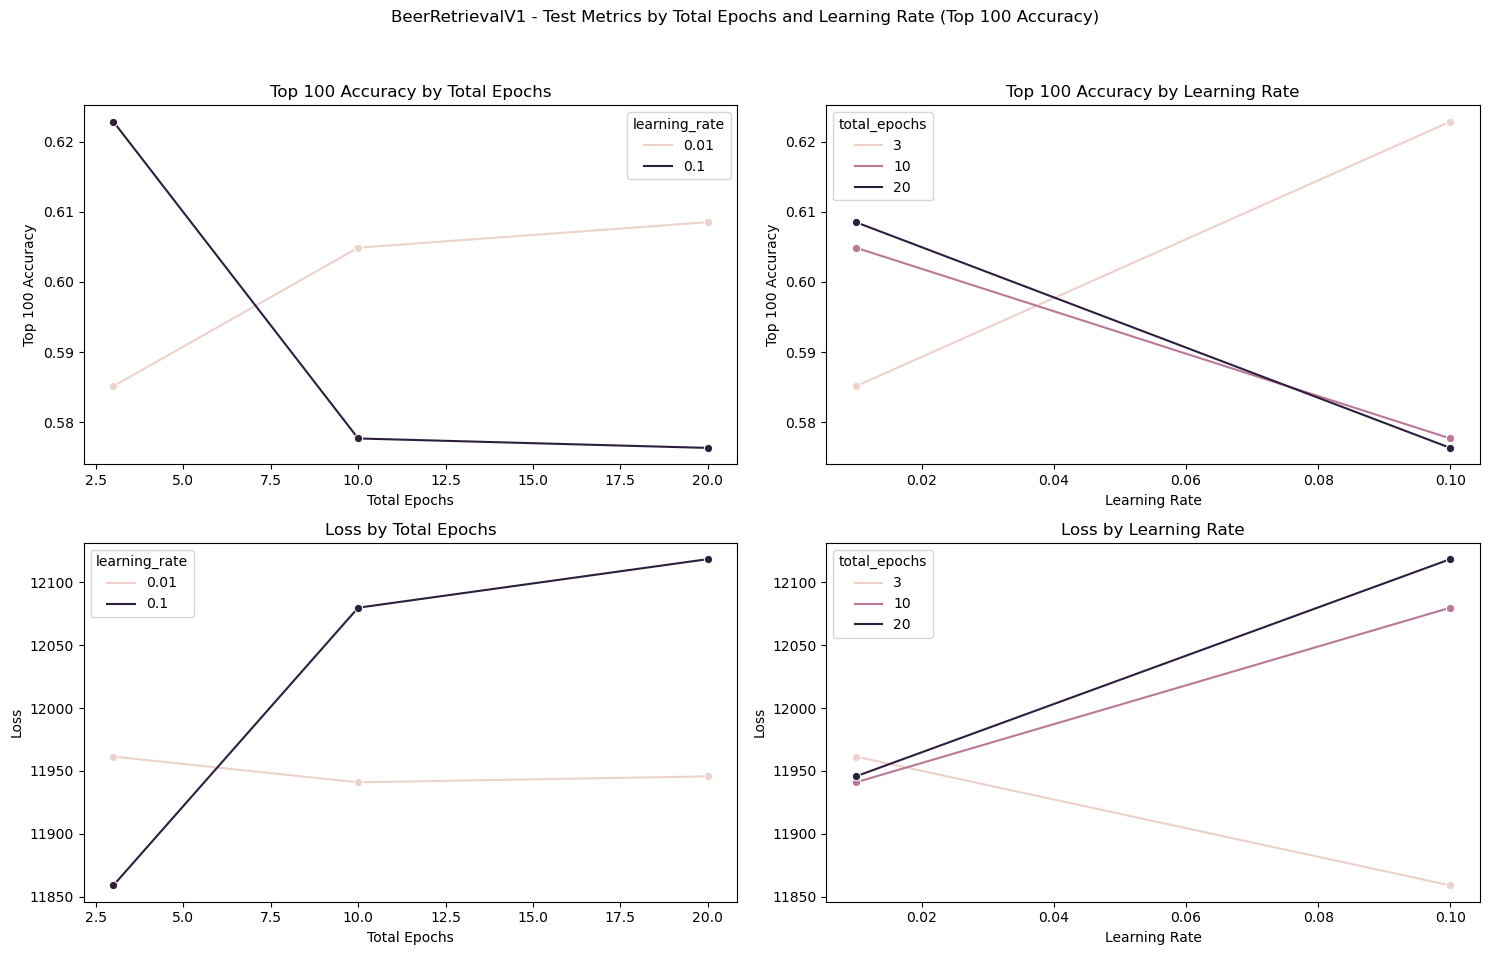

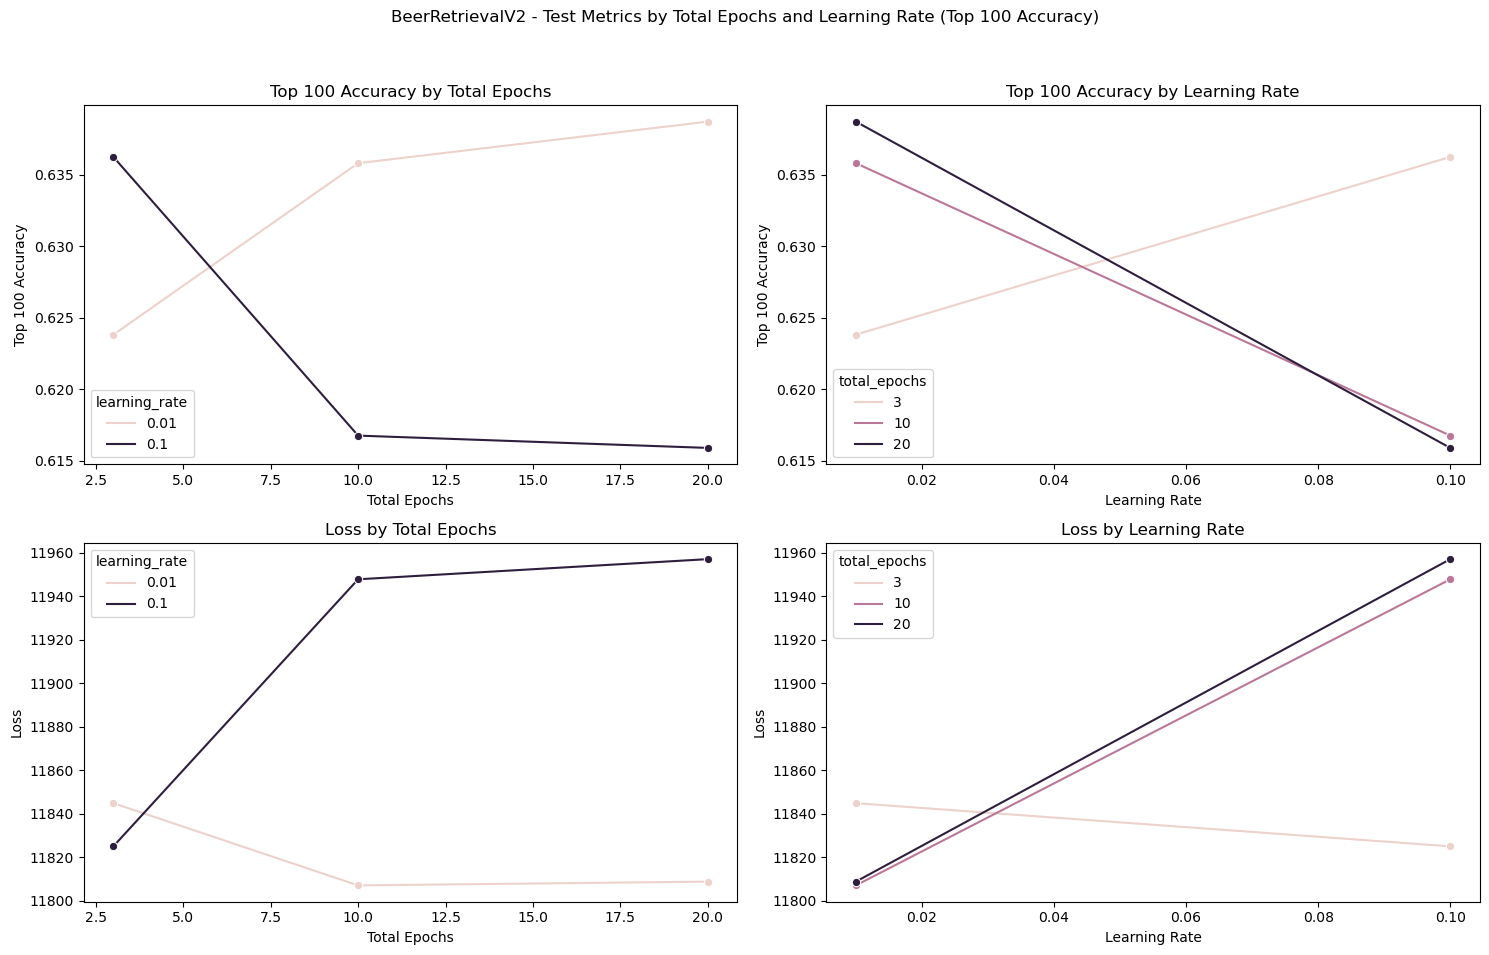

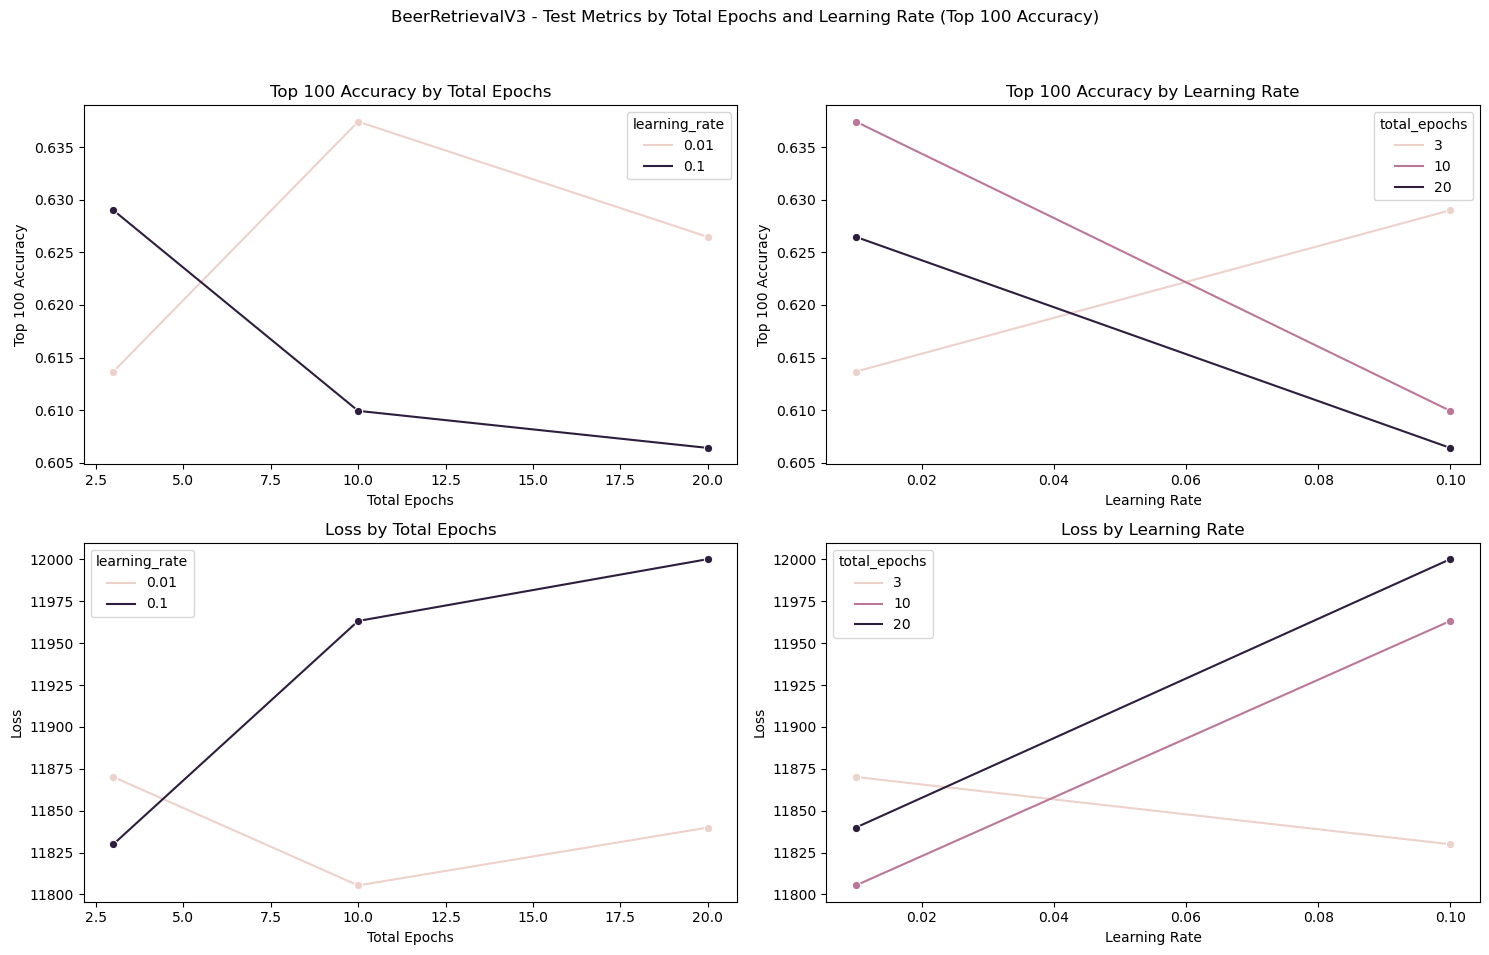

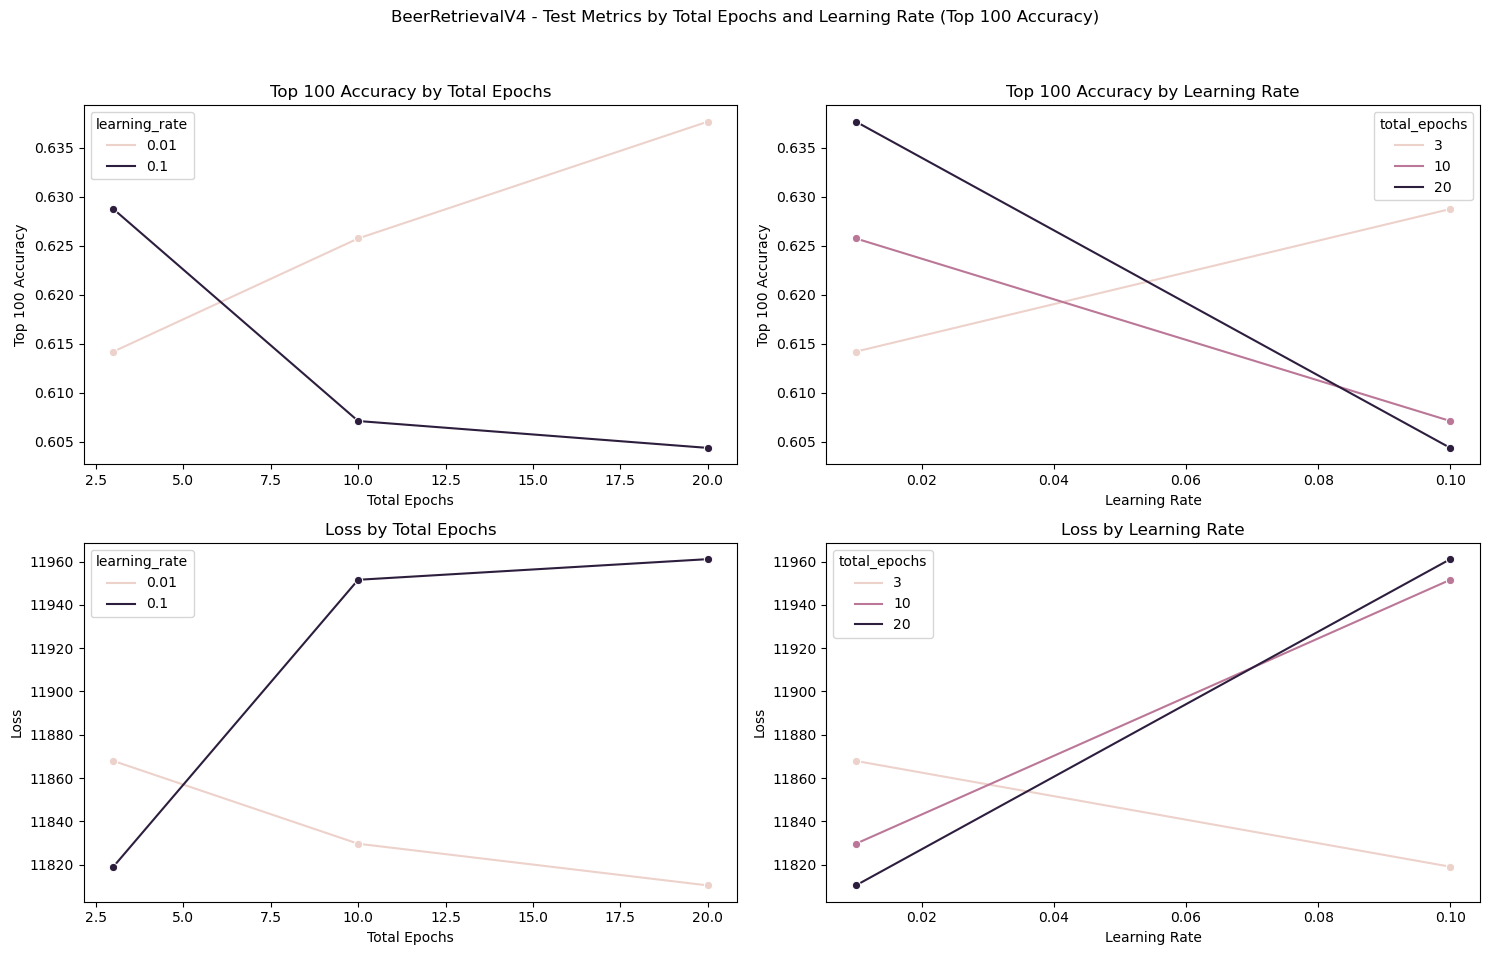

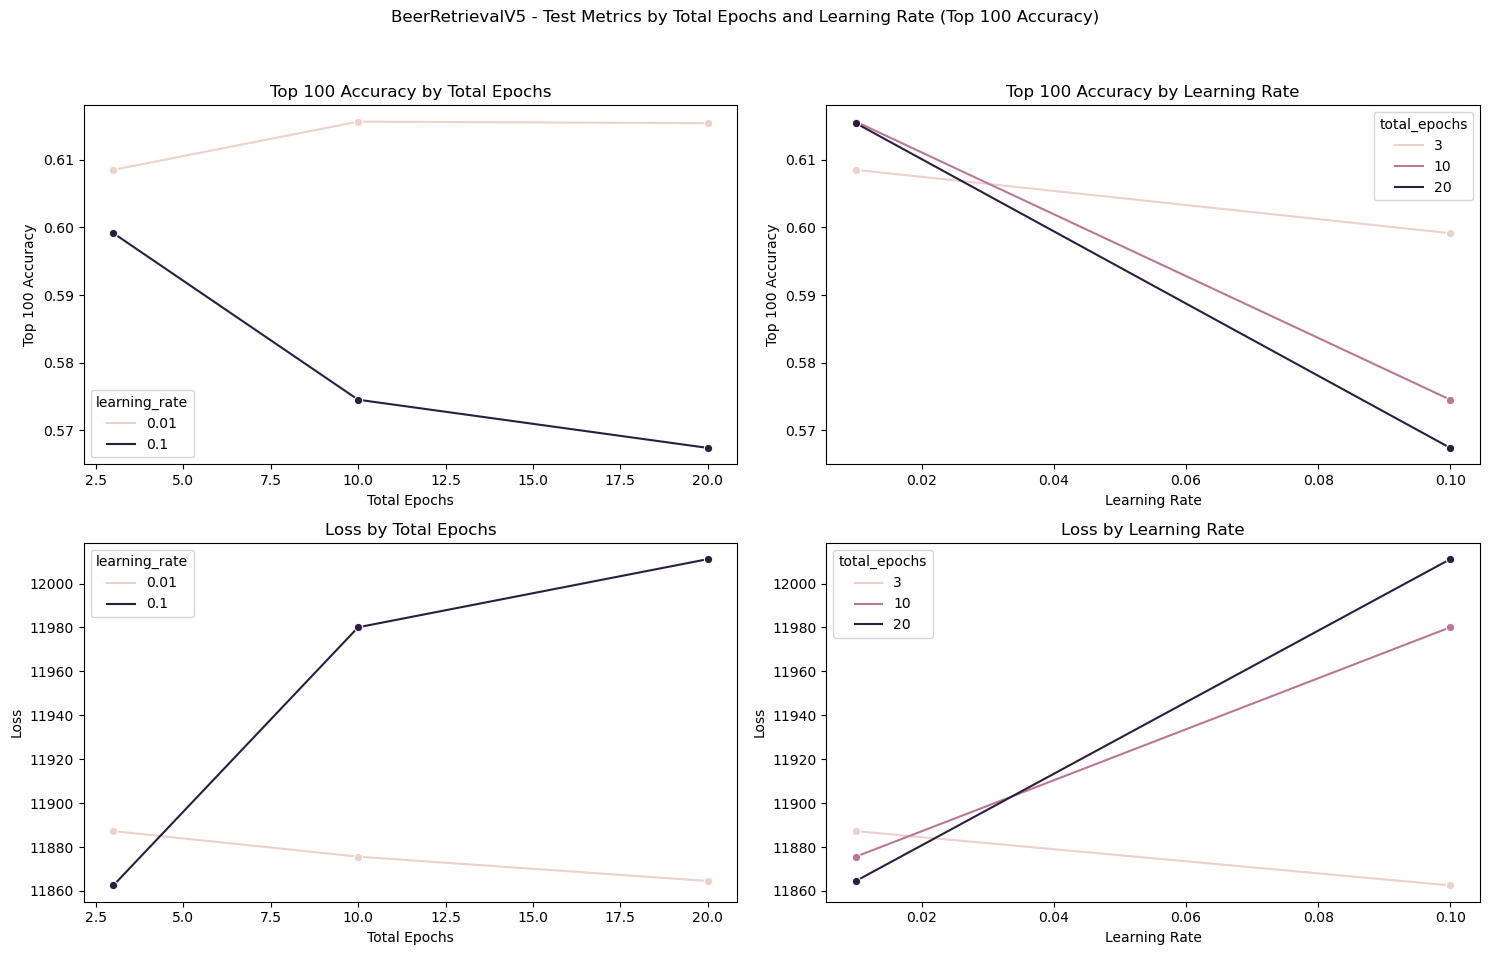

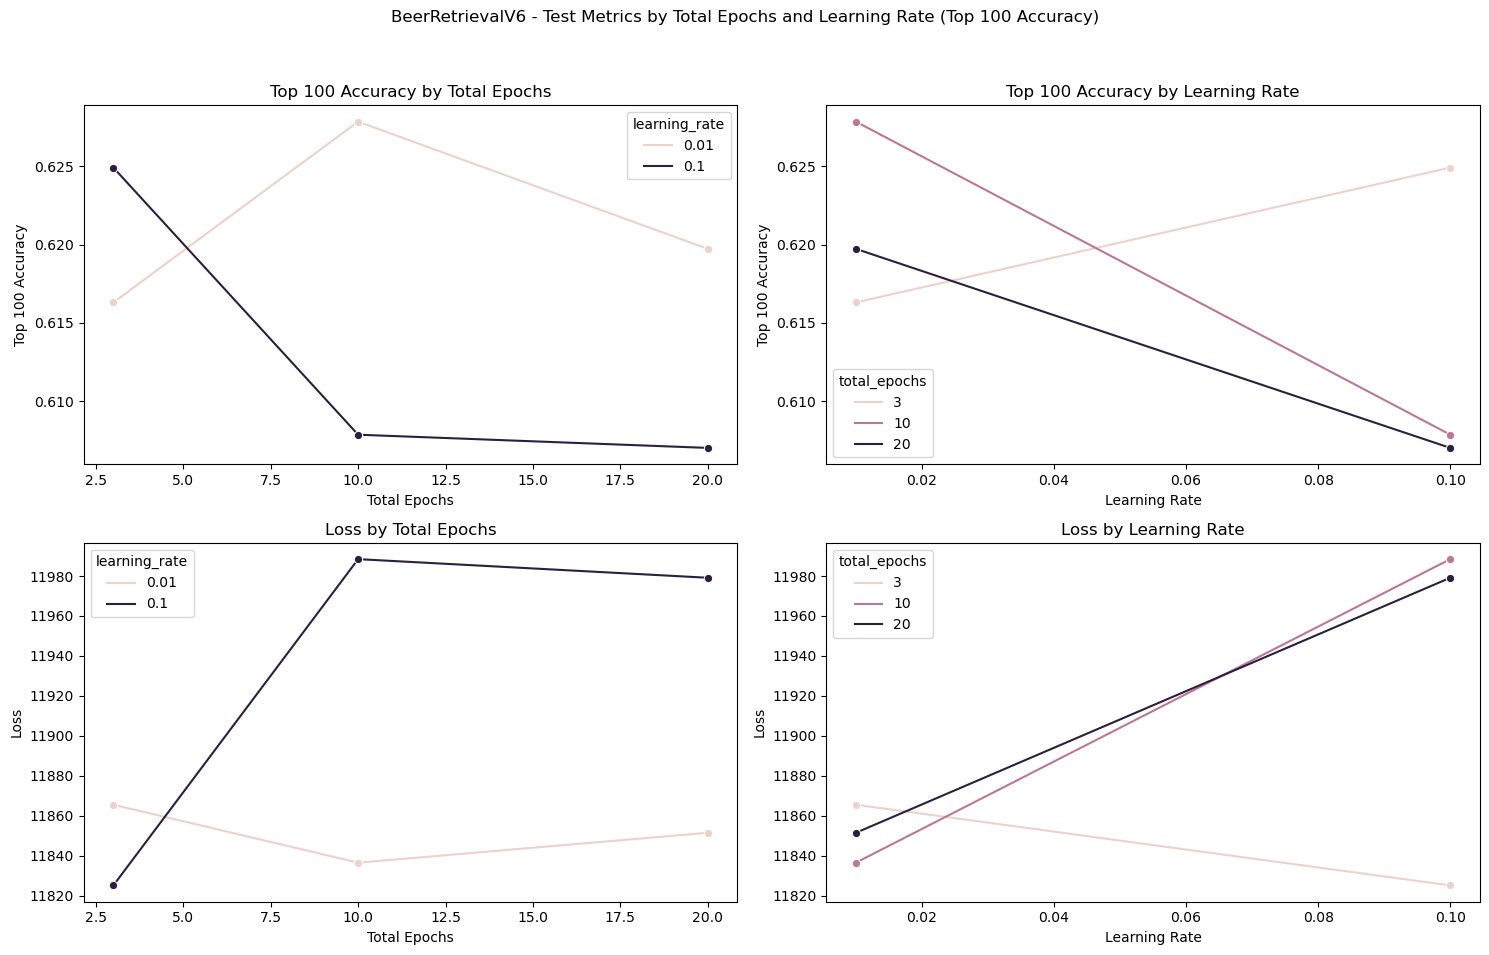

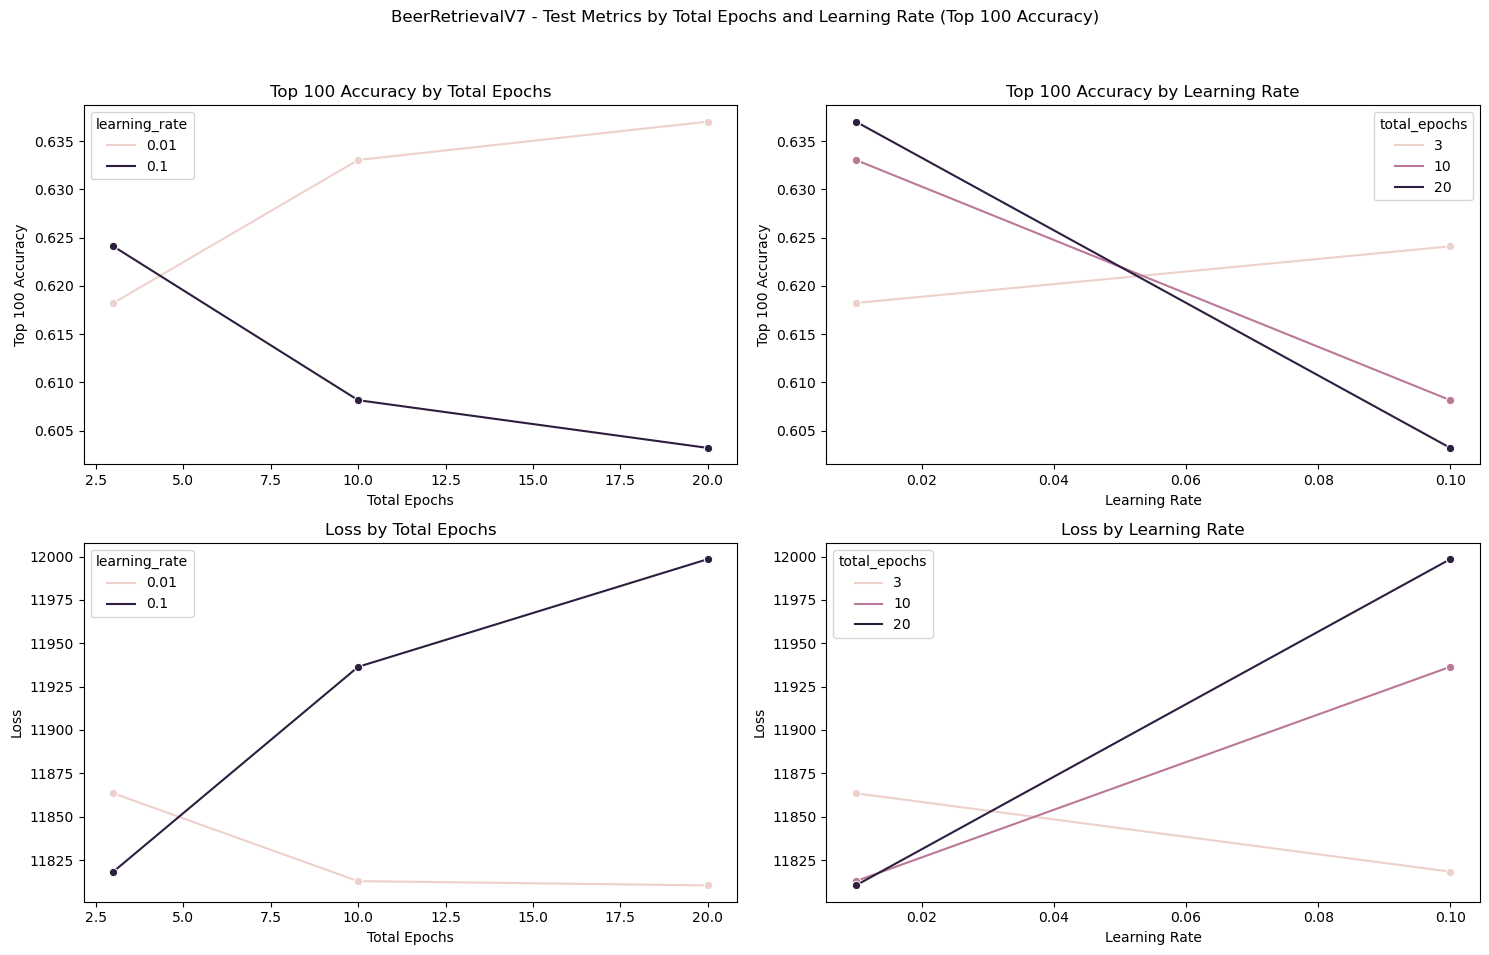

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_model_metrics_by_total_epochs_and_lr_top100(model_data, model_name):
    """
    Function to plot the metrics by total epochs and learning rate for a specific model, focusing on Top 100 Accuracy.
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f"{model_name} - Test Metrics by Total Epochs and Learning Rate (Top 100 Accuracy)")

    # Top 100 Accuracy by Total Epochs
    sns.lineplot(ax=axes[0, 0], data=model_data, x='total_epochs', y='top_100_accuracy', hue='learning_rate', marker="o")
    axes[0, 0].set_title("Top 100 Accuracy by Total Epochs")
    axes[0, 0].set_xlabel("Total Epochs")
    axes[0, 0].set_ylabel("Top 100 Accuracy")

    # Top 100 Accuracy by Learning Rate
    sns.lineplot(ax=axes[0, 1], data=model_data, x='learning_rate', y='top_100_accuracy', hue='total_epochs', marker="o")
    axes[0, 1].set_title("Top 100 Accuracy by Learning Rate")
    axes[0, 1].set_xlabel("Learning Rate")
    axes[0, 1].set_ylabel("Top 100 Accuracy")

    # Loss by Total Epochs
    sns.lineplot(ax=axes[1, 0], data=model_data, x='total_epochs', y='loss', hue='learning_rate', marker="o")
    axes[1, 0].set_title("Loss by Total Epochs")
    axes[1, 0].set_xlabel("Total Epochs")
    axes[1, 0].set_ylabel("Loss")

    # Loss by Learning Rate
    sns.lineplot(ax=axes[1, 1], data=model_data, x='learning_rate', y='loss', hue='total_epochs', marker="o")
    axes[1, 1].set_title("Loss by Learning Rate")
    axes[1, 1].set_xlabel("Learning Rate")
    axes[1, 1].set_ylabel("Loss")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Plotting for each model using total_epochs for Top 100 Accuracy
df_test_metrics = df_retrieval_metrics[df_retrieval_metrics['is_training'] == False]

#Make a plot for every model
model_names = ['BeerRetrievalV1', 'BeerRetrievalV2', 'BeerRetrievalV3', 'BeerRetrievalV4', 'BeerRetrievalV5', 'BeerRetrievalV6', 'BeerRetrievalV7']
for model_name in model_names:
    model_data = df_test_metrics[df_test_metrics['model_name'] == model_name]
    plot_model_metrics_by_total_epochs_and_lr_top100(model_data, model_name)

In [45]:
# Calculating the average top 100 accuracy for each model in the test data
average_top100_accuracy = df_test_metrics.groupby('model_name')['top_100_accuracy'].mean().sort_values(ascending=False)

print(average_top100_accuracy)

#V2 and V7 have the best performance
# Filtering data for BeerRetrievalV2 model
v2_data = df_test_metrics[df_test_metrics['model_name'] == 'BeerRetrievalV2']
v7_data = df_test_metrics[df_test_metrics['model_name'] == 'BeerRetrievalV7']


# Finding the combination of epochs and learning rate that gives the highest top 100 accuracy
best_performance_v2 = v2_data.loc[v2_data['top_100_accuracy'].idxmax(), ['total_epochs', 'learning_rate', 'top_100_accuracy']]
best_performance_v7 = v7_data.loc[v7_data['top_100_accuracy'].idxmax(), ['total_epochs', 'learning_rate', 'top_100_accuracy']]

print('Best hyperparameters for v2 :')
print(best_performance_v2)

print('Best hyperparameters for v7 :')
print(best_performance_v7)

model_name
BeerRetrievalV2    0.627881
BeerRetrievalV7    0.620626
BeerRetrievalV3    0.620483
BeerRetrievalV4    0.619639
BeerRetrievalV6    0.617283
BeerRetrievalV5    0.596765
BeerRetrievalV1    0.595910
Name: top_100_accuracy, dtype: float64
Best hyperparameters for v2 :
total_epochs              20
learning_rate           0.01
top_100_accuracy    0.638721
Name: 23, dtype: object
Best hyperparameters for v7 :
total_epochs              20
learning_rate           0.01
top_100_accuracy    0.637033
Name: 83, dtype: object


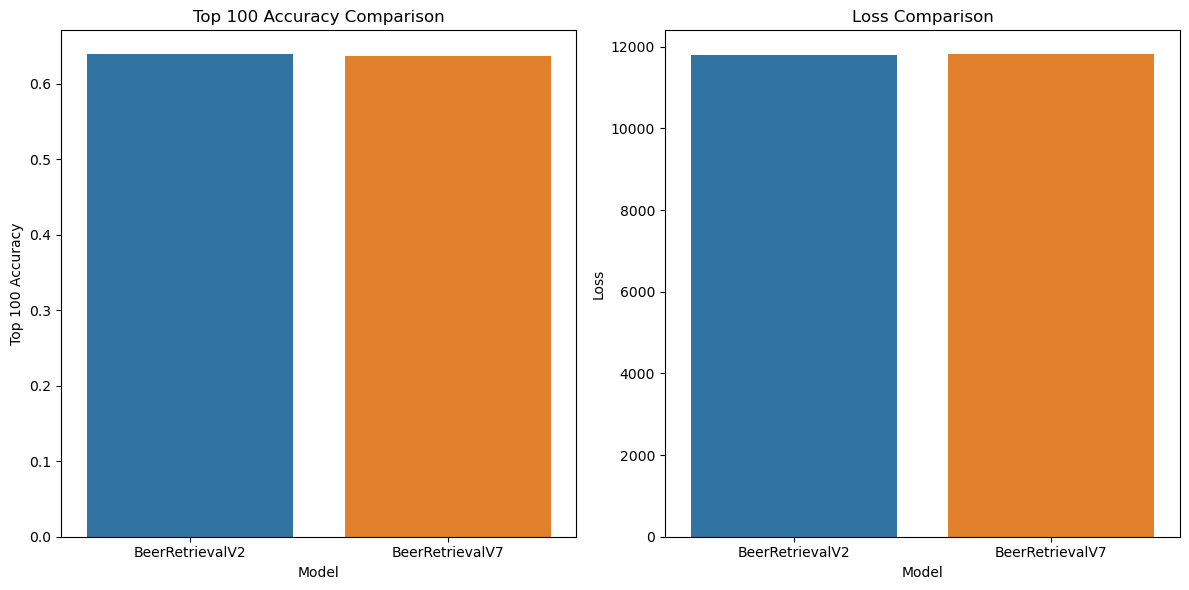

In [46]:
# Filtering data for BeerRetrievalV2 and BeerRetrievalV7 models with epochs = 20 and learning rate = 0.01
filtered_data = df_test_metrics[(df_test_metrics['model_name'].isin(['BeerRetrievalV2', 'BeerRetrievalV7'])) & 
                          (df_test_metrics['total_epochs'] == 20) & 
                          (df_test_metrics['learning_rate'] == 0.01)]

# Plotting accuracy and loss for these models under specified conditions
plt.figure(figsize=(12, 6))

# Top 100 Accuracy
plt.subplot(1, 2, 1)
sns.barplot(x="model_name", y="top_100_accuracy", data=filtered_data)
plt.title("Top 100 Accuracy Comparison")
plt.ylabel("Top 100 Accuracy")
plt.xlabel("Model")

# Loss
plt.subplot(1, 2, 2)
sns.barplot(x="model_name", y="loss", data=filtered_data)
plt.title("Loss Comparison")
plt.ylabel("Loss")
plt.xlabel("Model")

plt.tight_layout()
plt.show()

##### Model evalution
Given all the plots and statistics, v2 and v7 have very similar performance on test data (62%). 

The model execution time for v2 is much faster than v7. 

Please note that the accuracy is low as there are 66% of sparsity in the matrix. Plus, we only know about the username. It would be more accurate if we can have a better data on username (like country of origin, gender, age) 